# 03 - Multilingual Scam Classification (Modelling)

Fine-tune XLM-RoBERTa across 3 hyperparameter configurations (Exp 1-3), then apply the
winning configuration to two further experiments (WeightedRandomSampler, text normalisation) —
5 XLM-RoBERTa variants in total. The single best XLM-RoBERTa configuration is then reused
(token length + batch size) to train mBERT once as a frozen-encoder baseline. Track all runs
with MLflow on DagsHub. Evaluate with per-language F1, precision, recall, and AUC.

**Setup before running:**
1. Upload `train.csv`, `val.csv`, `test.csv`, `train_norm.csv`, `val_norm.csv`, `test_norm.csv` as a Kaggle Dataset
2. Add `DAGSHUB_TOKEN` and `HF_TOKEN` to Kaggle Secrets

**Input:** Kaggle dataset `/kaggle/input/datasets/bhoovika/scamscene-processed-dataset/`
**Output:** Models saved to `/kaggle/working/` then pushed to HuggingFace

| Section | Description |
|---|---|
| 1 | Install dependencies |
| 2 | MLflow + DagsHub config |
| 3 | Load and tokenise datasets |
| 4 | Model factory |
| 5 | Training loop (shared by all experiments) |
| 6 | Evaluation function (shared by all experiments) |
| 6.5 | Checkpoint-aware train/eval helper (shared by all experiments) |
| 7 | XLM-RoBERTa hyperparameter sweep — Exp 1-3, winner auto-selected |
| 8 | WeightedRandomSampler experiment (uses winning config) |
| 9 | Text normalisation experiment (uses winning config) |
| 10 | Consolidated XLM-RoBERTa comparison — all 5 variants |
| 11 | mBERT baseline (trained once, using winning config's tokens/batch) |
| 12 | Final comparison: best XLM-RoBERTa vs mBERT |
| 12a | ROC / Precision-Recall curves, best XLM-RoBERTa vs mBERT |
| 12b | Summary comparison chart, all experiments |
| 12c | Train vs test accuracy, over/underfitting check |
| 13 | Save best model + push to HuggingFace Hub |

**Note on reproducibility and re-runs:** every experiment (Section 7-11) is checkpoint-aware —
each one checks `MODELS_DIR` for a previously saved `{run_name}_best.pt` file before training.
If a checkpoint exists (e.g. from an earlier run of this same notebook, on the current
train/val/test splits), training is skipped and the checkpoint is loaded directly; either way,
train/validation/test metrics are always (re)computed with a fresh evaluation pass and logged to
`all_experiments_summary.csv`, `all_test_predictions.csv`, and `all_test_per_language.csv` in
`OUTPUT_DIR`. Sections 12 onward read only from these three files, so the rest of the notebook
does not depend on which experiments were freshly trained versus loaded from checkpoint in this
particular run.


## 1. Install dependencies

In [1]:
# =============================================================================
# CELL 1: Install dependencies
# -----------------------------------------------------------------------------
import os                                              # for filesystem paths and env vars
import warnings
warnings.filterwarnings('ignore')                      # hide non-critical library warnings (keeps output clean)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'          # silences a HuggingFace tokenizer fork warning
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'          # only show errors from transformers, not info/warnings

import numpy as np                                      # numeric arrays (used throughout for metrics/plots)
import pandas as pd                                     # DataFrames for all results tables and CSVs
import torch                                            # PyTorch: model training/inference

import transformers
transformers.logging.set_verbosity_error()              # same as above, belt-and-braces for the library logger

# Installs/updates the exact libraries this notebook needs on a fresh Kaggle kernel.
# -q = quiet, redirected to /dev/null so it doesn't clutter the notebook output.
!pip install -q transformers mlflow dagshub accelerate huggingface_hub > /dev/null 2>&1

# -- Kaggle paths --------------------------------------------------------------
INPUT_DIR  = '/kaggle/input/datasets/bhoovika/scamscene-processed-dataset'  # read-only: uploaded CSVs live here
OUTPUT_DIR = '/kaggle/working'                          # writable: everything this notebook produces goes here
MODELS_DIR = f'{OUTPUT_DIR}/models'                     # sub-folder for saved model checkpoints
os.makedirs(MODELS_DIR, exist_ok=True)                  # create it if it doesn't exist yet; no error if it does

# -- Device selection -----------------------------------------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # use GPU if Kaggle gave us one
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')                      # e.g. "Tesla P100-PCIE-16GB"
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


## 2. MLflow + DagsHub configuration

In [2]:
# =============================================================================
# CELL 2: MLflow + DagsHub configuration
# -----------------------------------------------------------------------------
import mlflow                                           # experiment tracking (logs params/metrics per run)
import dagshub                                           # hosts the MLflow tracking server for this project
from kaggle_secrets import UserSecretsClient             # reads secrets stored in Kaggle's "Add-ons > Secrets"

secrets = UserSecretsClient()                            # client used to fetch secrets by name
DAGSHUB_TOKEN    = secrets.get_secret('DAGSHUB_TOKEN')    # personal access token for DagsHub (must be added as a Kaggle Secret)
DAGSHUB_USERNAME = 'Bhoovika'

# MLflow needs these two env vars to authenticate against the remote (DagsHub) tracking server
os.environ['MLFLOW_TRACKING_USERNAME'] = DAGSHUB_USERNAME
os.environ['MLFLOW_TRACKING_PASSWORD'] = DAGSHUB_TOKEN

# One-time handshake that tells the dagshub library which repo to treat as the MLflow backend
dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name='ScamSense',
    mlflow=True,
)
mlflow.set_tracking_uri('https://dagshub.com/Bhoovika/ScamSense.mlflow')   # where runs get logged to
mlflow.set_experiment('scamsense-classification')                          # groups all runs under one experiment name

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('View runs at: https://dagshub.com/Bhoovika/ScamSense.mlflow')


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=1a6ba464-a5b1-4d5a-9a95-b1fedf70a3f6&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=5599bb849d5af3ec697f7a177a2946f531418e1586634ffd30143020ea68c925




Accessing as Bhoovika

Initialized MLflow to track repo "Bhoovika/ScamSense"

Repository Bhoovika/ScamSense initialized!

MLflow tracking URI: https://dagshub.com/Bhoovika/ScamSense.mlflow
View runs at: https://dagshub.com/Bhoovika/ScamSense.mlflow


## 3. Load datasets and tokenise

In [3]:
# =============================================================================
# CELL 3: Load datasets and tokenise
# -----------------------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader        # base classes for feeding batches to PyTorch
from transformers import AutoTokenizer                  # loads the correct tokenizer for any HF model name

BATCH_SIZE = 32  # default batch size; overridden per-experiment where noted


def load_split(filename):
    """Reads a CSV either from the Kaggle input dataset or from OUTPUT_DIR
    (so re-runs can find files this notebook itself already saved)."""
    kaggle_path  = f'{INPUT_DIR}/{filename}'             # first choice: the uploaded, read-only dataset
    working_path = f'{OUTPUT_DIR}/{filename}'            # fallback: a copy already sitting in /kaggle/working
    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path, encoding='utf-8-sig')
    elif os.path.exists(working_path):
        return pd.read_csv(working_path, encoding='utf-8-sig')
    else:
        raise FileNotFoundError(
            f'{filename} not found. Upload train/val/test.csv as a Kaggle Dataset '
            f'and attach it to this notebook.'
        )


# Load the three main splits and drop any row with a missing message (can't train/eval on those)
df_train = load_split('train.csv').dropna(subset=['text']).reset_index(drop=True)
df_val   = load_split('val.csv').dropna(subset=['text']).reset_index(drop=True)
df_test  = load_split('test.csv').dropna(subset=['text']).reset_index(drop=True)

for df in [df_train, df_val, df_test]:
    # 'strat_key' was only needed for the stratified split in NB02 -- not needed for training
    df.drop(columns=[c for c in ['strat_key'] if c in df.columns], inplace=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'Train label balance: {df_train["label"].value_counts().to_dict()}')


class ScamSenseDataset(Dataset):
    """PyTorch Dataset for tokenised scam/ham messages.

    Tokenises in chunks (default 2,000 rows at a time) rather than building one
    giant tensor for the whole split in a single tokenizer call. This caps peak
    RAM during tokenisation -- important on Kaggle's ~13GB RAM environment,
    where tokenising ~95K rows at max_length=512 in one shot can OOM the kernel,
    even though the final stored tensors themselves would fit comfortably.
    """

    def __init__(self, df, tokenizer, max_length=128, chunk_size=2000):
        self.labels = df['label'].tolist()               # 0 = ham, 1 = scam
        self.langs  = df['language'].tolist()             # kept alongside so metrics can be broken down per language
        texts = df['text'].tolist()

        input_ids_chunks = []
        attn_mask_chunks = []
        for start in range(0, len(texts), chunk_size):    # process `chunk_size` rows at a time
            chunk = texts[start:start + chunk_size]
            enc_chunk = tokenizer(
                chunk,
                padding='max_length',                     # pad every sequence to the same length (needed for batching)
                truncation=True,                          # cut off anything longer than max_length
                max_length=max_length,
                return_tensors='pt',                      # return PyTorch tensors directly
            )
            input_ids_chunks.append(enc_chunk['input_ids'])
            attn_mask_chunks.append(enc_chunk['attention_mask'])

        # Stitch all the per-chunk tensors back into one tensor covering the whole split
        self.input_ids      = torch.cat(input_ids_chunks, dim=0)
        self.attention_mask = torch.cat(attn_mask_chunks, dim=0)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # PyTorch calls this once per example per batch -- must return a dict of tensors/values
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
            'language':       self.langs[idx],
        }


def build_loaders(model_name, max_length=128, batch_size=32, train_df=None, val_df=None, test_df=None):
    """Tokenise all splits with the given model's tokeniser.
    Pass train_df/val_df/test_df to override the default df_train/df_val/df_test
    (used by the text-normalisation experiment, which loads a separate set of CSVs).
    """
    train_df = df_train if train_df is None else train_df   # allow callers to substitute different data
    val_df   = df_val   if val_df   is None else val_df
    test_df  = df_test  if test_df  is None else test_df

    print(f'Tokenising with {model_name}  (max_length={max_length}, batch_size={batch_size})...')
    tokenizer  = AutoTokenizer.from_pretrained(model_name)     # loads the tokenizer that matches the model
    train_ds   = ScamSenseDataset(train_df, tokenizer, max_length)
    val_ds     = ScamSenseDataset(val_df,   tokenizer, max_length)
    test_ds    = ScamSenseDataset(test_df,  tokenizer, max_length)
    # shuffle=True only for training -- val/test order doesn't matter and shuffling them would waste time
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    print(f'Loaders ready: {len(train_loader)} train batches')
    return tokenizer, train_loader, val_loader, test_loader


Train: 95,851 | Val: 20,539 | Test: 20,540
Train label balance: {0: 47926, 1: 47925}


## 4. Model factory

In [4]:
# =============================================================================
# CELL 4: Model factory
# -----------------------------------------------------------------------------
# freeze_encoder=False  -> full fine-tune (XLM-RoBERTa, all experiments)
# freeze_encoder=True   -> frozen encoder, head only (mBERT fast baseline)
# =============================================================================
from transformers import AutoModelForSequenceClassification   # generic HF class for classification heads

def build_model(model_name, freeze_encoder=False):
    # num_labels=2 -> binary classification (ham vs scam)
    # ignore_mismatched_sizes=True -> lets us reuse a pretrained checkpoint even though its
    # original classification head (usually sized for a different task) doesn't match ours
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    )
    if freeze_encoder:
        # Freeze every parameter except the classifier/pooler head -- turns this into a
        # "linear probe" on top of fixed pretrained features (cheap, fast baseline)
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'pooler' not in name:
                param.requires_grad = False
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        print(f'Frozen encoder: {trainable:,} / {total:,} params trainable')
    else:
        total = sum(p.numel() for p in model.parameters())
        print(f'Full fine-tune: {total:,} params trainable')
    return model.to(DEVICE)   # move all weights onto GPU (or CPU if no GPU available)


## 5. Training loop (shared by all experiments)

Used by every experiment in this notebook (Exp 1-5, WRS, text-normalisation, mBERT) so that
all runs are trained, validated, and checkpointed identically — the only things that differ
between experiments are the data loaders and hyperparameters passed in.

**Fix applied:** the training loop now performs exactly one pass over `train_loader` per epoch
(an earlier version of this notebook accidentally looped over the training batches twice per
epoch, doubling both runtime and the optimizer step count without it being reflected in the logs).
Training accuracy and F1 are now computed from the same pass — no second pass needed.


In [5]:
# =============================================================================
# CELL 5: Training loop with rich per-epoch output
# =============================================================================
import torch.nn as nn                                    # neural-net building blocks (loss functions etc.)
from torch.optim import AdamW                             # optimizer used for fine-tuning
from transformers import get_linear_schedule_with_warmup  # LR schedule: warm up, then linearly decay
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score  # metric helpers
import time                                                # for timing each epoch
from tqdm.auto import tqdm                                 # progress bar for training batches

def train_model(model, model_name, run_name, train_loader, val_loader,
                 epochs=3, lr=2e-5, warmup_ratio=0.1, freeze_encoder=False,
                 batch_size=None, max_length=None, log_to_mlflow=True):
    """Trains `model` for `epochs` epochs, validating after every epoch.
    Saves the best checkpoint (by val F1) to MODELS_DIR/{run_name}_best.pt
    and restores it if early stopping triggers.
    Returns (checkpoint_path, history_dict).
    """
    batch_size = batch_size or BATCH_SIZE                 # fall back to the global default if none given

    optimizer    = AdamW([p for p in model.parameters() if p.requires_grad],   # only update unfrozen params
                          lr=lr, weight_decay=0.01)
    total_steps  = len(train_loader) * epochs              # total optimizer steps across all epochs
    warmup_steps = int(total_steps * warmup_ratio)          # steps spent ramping the LR up from 0
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler       = torch.cuda.amp.GradScaler()              # scales gradients to prevent underflow in mixed precision
    loss_fn      = nn.CrossEntropyLoss()                    # standard loss for multi-class/binary classification
    best_val_f1  = -float('inf')                            # tracks the best validation F1 seen so far
    best_ckpt    = f'{MODELS_DIR}/{run_name}_best.pt'        # where the best-so-far weights get saved
    no_improve   = 0                                        # counts consecutive epochs with no val F1 improvement
    patience     = 1                                        # stop early after this many non-improving epochs

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss':   [], 'val_acc':   [], 'val_f1':   [],
        'val_precision': [], 'val_recall': []
    }

    print(f"\n{'='*65}")
    print(f"  MODEL : {model_name}")
    print(f"  RUN   : {run_name}")
    print(f"  LR={lr} | Batch={batch_size} | Epochs={epochs}")
    print(f"{'='*65}\n")

    run_ctx = mlflow.start_run(run_name=run_name) if log_to_mlflow else _nullcontext()
    with run_ctx:
        if log_to_mlflow:
            mlflow.log_params({
                'model_name': model_name, 'freeze_encoder': freeze_encoder,
                'epochs': epochs, 'learning_rate': lr, 'batch_size': batch_size,
                'warmup_ratio': warmup_ratio,
                'train_size': len(train_loader.dataset), 'val_size': len(val_loader.dataset),
            })

        for epoch in range(epochs):
            # -- Training (single pass) -------------------------------------
            model.train()                                   # enable dropout etc. for training mode
            train_loss        = 0.0                         # running sum of batch losses this epoch
            train_batch_preds = []                          # predicted labels, collected across all batches
            train_batch_lbls  = []                          # true labels, collected across all batches
            t0 = time.time()                                # start the epoch timer

            pbar = tqdm(train_loader, desc=f"  Ep{epoch+1} train",   # progress bar over training batches
                        unit="batch", ncols=80, leave=False)

            for batch in pbar:
                ids  = batch['input_ids'].to(DEVICE)        # move token ids to GPU/CPU device
                mask = batch['attention_mask'].to(DEVICE)   # move attention mask to device
                lbls = batch['labels'].to(DEVICE)           # move true labels to device
                optimizer.zero_grad()                       # clear gradients from the previous step
                with torch.cuda.amp.autocast():              # mixed precision forward pass (faster, less memory)
                    logits = model(input_ids=ids, attention_mask=mask).logits
                    loss   = loss_fn(logits, lbls)
                scaler.scale(loss).backward()                # scaled backward pass (mixed precision)
                scaler.unscale_(optimizer)                   # unscale gradients before clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # cap gradient norm to stabilise training
                scaler.step(optimizer)                       # optimizer step (skipped if gradients overflowed)
                scaler.update()                              # adjust the scaler for the next iteration
                scheduler.step()                             # advance the LR schedule by one step
                train_loss += loss.item()                    # accumulate this batch's loss
                train_batch_preds.extend(torch.argmax(logits.detach(), dim=1).cpu().numpy())  # store predictions
                train_batch_lbls.extend(lbls.cpu().numpy())  # store true labels
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})  # show current batch loss on the progress bar

            pbar.close()                                     # close the progress bar for this epoch

            avg_train = train_loss / len(train_loader)       # mean training loss over all batches
            train_acc = accuracy_score(train_batch_lbls, train_batch_preds)
            train_f1  = f1_score(train_batch_lbls, train_batch_preds, average='weighted')

            # -- Validation ---------------------------------------------------
            model.eval()                                     # disable dropout etc. for evaluation
            val_loss   = 0.0                                 # running sum of validation batch losses
            all_preds  = []                                  # predicted labels across all val batches
            all_labels = []                                  # true labels across all val batches
            with torch.no_grad():                            # no gradient tracking needed during validation
                for batch in val_loader:
                    ids  = batch['input_ids'].to(DEVICE)
                    mask = batch['attention_mask'].to(DEVICE)
                    lbls = batch['labels'].to(DEVICE)
                    with torch.cuda.amp.autocast():           # mixed precision forward pass
                        out  = model(input_ids=ids, attention_mask=mask)
                        loss = loss_fn(out.logits, lbls)
                    val_loss += loss.item()                   # accumulate this batch's loss
                    all_preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())  # store predictions
                    all_labels.extend(lbls.cpu().numpy())     # store true labels

            avg_val  = val_loss / len(val_loader)              # mean validation loss over all batches
            val_f1   = f1_score(all_labels, all_preds, average='weighted')
            val_acc  = accuracy_score(all_labels, all_preds)
            val_prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
            val_rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
            elapsed  = time.time() - t0                        # total time spent on this epoch
            cur_lr   = scheduler.get_last_lr()[0]               # current learning rate, for logging

            history['train_loss'].append(avg_train)            # record this epoch's metrics into history
            history['train_acc'].append(train_acc)
            history['train_f1'].append(train_f1)
            history['val_loss'].append(avg_val)
            history['val_f1'].append(val_f1)
            history['val_acc'].append(val_acc)
            history['val_precision'].append(val_prec)
            history['val_recall'].append(val_rec)

            improved = val_f1 > best_val_f1                     # did this epoch beat the best-so-far val F1?
            print(f"Epoch {epoch+1}/{epochs}  [{elapsed:.0f}s]")
            print(f"  Train Loss : {avg_train:.4f}  |  Train Acc: {train_acc:.4f}  |  Train F1: {train_f1:.4f}")
            print(f"  Val Loss   : {avg_val:.4f}  |  Val Acc:   {val_acc:.4f}  |  Val F1:   {val_f1:.4f}")
            print(f"  Precision  : {val_prec:.4f}  |  Recall:    {val_rec:.4f}  |  LR:       {cur_lr:.2e}")

            if improved:
                print(f"  Val F1 improved ({best_val_f1:.4f} -> {val_f1:.4f}) -- checkpoint saved")
                best_val_f1 = val_f1                             # update the best-so-far F1
                torch.save(model.state_dict(), best_ckpt)        # save these weights as the new best checkpoint
                no_improve  = 0                                  # reset the non-improvement streak
            else:
                no_improve += 1                                  # extend the non-improvement streak
                print(f"  Val F1 did not improve ({best_val_f1:.4f}). No-improve streak: {no_improve}/{patience}")
                if no_improve >= patience:
                    print(f"\n  Early stopping triggered at epoch {epoch+1}. Restoring best weights.")
                    model.load_state_dict(torch.load(best_ckpt))  # reload the best checkpoint before stopping
                    break                                         # exit the epoch loop early
            print()

            if log_to_mlflow:
                mlflow.log_metrics({                              # log this epoch's metrics to MLflow
                    'train_loss': avg_train, 'train_acc': train_acc,
                    'val_loss': avg_val,     'val_f1': val_f1, 'val_acc': val_acc
                }, step=epoch)

        if log_to_mlflow:
            mlflow.log_metric('best_val_f1', best_val_f1)         # log the final best F1 for this run
            mlflow.log_artifact(best_ckpt)                        # attach the checkpoint file to the MLflow run

    print(f"{'='*65}")
    print(f"  Training complete -- Best Val F1: {best_val_f1:.4f}")
    print(f"  Checkpoint: {best_ckpt}")
    print(f"{'='*65}")
    return best_ckpt, history


class _nullcontext:
    """Fallback no-op context manager for runs we don't want logged to MLflow individually
    (e.g. quick tuning sweeps) -- keeps the function signature uniform."""
    def __enter__(self): return None
    def __exit__(self, *a): return False


print("train_model() ready.")


train_model() ready.


## 6. Evaluation function (shared by all experiments)

In [6]:
# =============================================================================
# CELL 6: Evaluation function -- returns metrics + raw arrays for plotting
# -----------------------------------------------------------------------------
import torch.nn.functional as F                          # for softmax and cross-entropy in eval mode
from sklearn.metrics import (                              # metric helpers used throughout evaluation
    f1_score, precision_score, recall_score,
    roc_auc_score, accuracy_score, classification_report, confusion_matrix
)

def evaluate_model(model, loader, split_name, run_name, verbose=True):
    """
    Evaluates model on any loader (val or test).
    Prints clean metrics table + classification report (if verbose).
    Returns (results_df, all_labels, all_preds, all_probs, all_langs).
    """
    model.eval()                                          # inference mode: no dropout, no gradient updates
    all_preds, all_probs, all_labels, all_langs = [], [], [], []   # accumulators across all batches
    total_loss, n_batches = 0.0, 0                          # for computing average loss at the end

    with torch.no_grad():                                   # no gradients needed for evaluation
        for batch in loader:
            ids    = batch['input_ids'].to(DEVICE)          # move token ids to device
            mask   = batch['attention_mask'].to(DEVICE)     # move attention mask to device
            labels = batch['labels'].to(DEVICE)             # move true labels to device
            with torch.cuda.amp.autocast():                  # mixed precision forward pass
                out  = model(input_ids=ids, attention_mask=mask)
                loss = F.cross_entropy(out.logits, labels)
            total_loss += loss.item()                        # accumulate this batch's loss
            n_batches  += 1                                   # count batches for the average
            probs = F.softmax(out.logits, dim=1)[:, 1].cpu().numpy()   # predicted probability of the 'scam' class
            preds = torch.argmax(out.logits, dim=1).cpu().numpy()      # predicted class label
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_langs.extend(batch['language'])

    all_preds  = np.array(all_preds)                         # convert accumulated lists to arrays for sklearn
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    avg_loss   = total_loss / n_batches                      # mean loss across all batches

    acc   = accuracy_score(all_labels, all_preds)            # overall accuracy
    f1    = f1_score(all_labels, all_preds, average='weighted')       # overall weighted F1
    prec  = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec   = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)            # AUC-ROC using predicted probabilities
    except ValueError:
        auc = None                                            # fails if only one class is present in this split

    if verbose:
        print(f"\n{'='*55}")
        print(f"  {run_name} -- {split_name} Results")
        print(f"{'='*55}")
        print(f"  Loss      : {avg_loss:.4f}")
        print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
        print(f"  Precision : {prec:.4f}")
        print(f"  Recall    : {rec:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        if auc:
            print(f"  AUC-ROC   : {auc:.4f}")
        print(f"\nClassification Report ({split_name}):\n")
        print(classification_report(all_labels, all_preds, target_names=['Ham', 'Scam']))

    lang_rows = []                                          # will hold one metrics dict per language
    for lang in sorted(set(all_langs)):
        idx = np.array([i for i, l in enumerate(all_langs) if l == lang])   # indices of rows for this language
        lf1   = f1_score(all_labels[idx], all_preds[idx], average='weighted')
        lacc  = accuracy_score(all_labels[idx], all_preds[idx])
        lprec = precision_score(all_labels[idx], all_preds[idx], average='weighted', zero_division=0)
        lrec  = recall_score(all_labels[idx], all_preds[idx], average='weighted', zero_division=0)
        try:
            lauc = roc_auc_score(all_labels[idx], all_probs[idx])   # AUC for just this language's rows
        except ValueError:
            lauc = None                                     # fails if this language has only one class present
        lang_rows.append({'language': lang, 'accuracy': round(lacc,4), 'precision': round(lprec,4),
                           'recall': round(lrec,4), 'f1': round(lf1,4), 'auc': round(lauc,4) if lauc else None})
        if verbose:
            auc_str = f"{lauc:.4f}" if lauc is not None else "N/A"
            print(f"  {lang:10s}: Acc={lacc:.4f}  Prec={lprec:.4f}  Rec={lrec:.4f}  F1={lf1:.4f}  AUC={auc_str}")

    overall_row = {'language': 'overall', 'accuracy': round(acc,4), 'precision': round(prec,4),
                    'recall': round(rec,4), 'f1': round(f1,4), 'auc': round(auc,4) if auc else None}
    results_df = pd.DataFrame([overall_row] + lang_rows)

    return results_df, all_labels, all_preds, all_probs, all_langs

print("evaluate_model() ready.")


evaluate_model() ready.


## 6.5 Shared checkpoint-aware train/eval helper

Wraps `train_model()` + `evaluate_model()` so that every experiment in Sections 7-11:

1. Skips training and loads the checkpoint directly if `MODELS_DIR/{run_name}_best.pt`
   already exists (e.g. from an earlier run of this notebook on the same data splits) --
   saves GPU hours when only later sections need re-running.
2. Either way, always (re)computes train/validation/test metrics with one fresh evaluation
   pass, and logs them to three running CSVs in `OUTPUT_DIR`:
   - `all_experiments_summary.csv` -- one row per experiment, scalar metrics only
   - `all_test_predictions.csv` -- one row per test example per experiment (true label +
     predicted probability), needed for the ROC/PR curves in Section 12a
   - `all_test_per_language.csv` -- one row per language per experiment, needed for the
     per-language comparisons in Sections 10 and 12

Sections 12 onward read only from these three files, so nothing downstream depends on
which experiments were freshly trained versus loaded from checkpoint in this run.


In [7]:
# =============================================================================
# CELL 6.5: train_or_load() -- checkpoint-aware training + always-on CSV logging
# =============================================================================
ALL_SUMMARY_CSV     = f'{OUTPUT_DIR}/all_experiments_summary.csv'   # scalar metrics, 1 row per experiment
ALL_PREDICTIONS_CSV = f'{OUTPUT_DIR}/all_test_predictions.csv'      # raw per-example test predictions (for ROC/PR)
ALL_PERLANG_CSV     = f'{OUTPUT_DIR}/all_test_per_language.csv'     # per-language test metrics, 1 row per language


def _upsert_csv(path, new_rows_df, key_col='experiment'):
    """Writes new_rows_df into the CSV at `path`, replacing any existing rows that
    share the same key_col value first. This means re-running an experiment cell
    overwrites its old numbers cleanly instead of duplicating rows."""
    if os.path.exists(path):
        existing = pd.read_csv(path)                                    # load whatever is already saved
        existing = existing[~existing[key_col].isin(new_rows_df[key_col].unique())]  # drop this run's old rows, if any
        combined = pd.concat([existing, new_rows_df], ignore_index=True)  # add the fresh rows back in
    else:
        combined = new_rows_df                                          # first time -- nothing to merge with
    combined.to_csv(path, index=False)


def train_or_load(model, model_name, run_name, label, train_loader, val_loader, test_loader,
                   epochs=10, lr=2e-5, freeze_encoder=False, batch_size=None, max_length=None,
                   log_to_mlflow=True):
    """
    label    : short display name used across the notebook, e.g. 'Exp 1', 'WRS', 'mBERT'
    run_name : checkpoint / MLflow run identifier, e.g. 'xlmroberta-exp1'

    Returns a dict:
        ckpt_path, history (None if loaded from checkpoint instead of trained),
        train_acc,
        df_val, val_true, val_preds, val_probs,
        df_test, test_true, test_preds, test_probs
    """
    ckpt_path = f'{MODELS_DIR}/{run_name}_best.pt'   # checkpoint filename is always this fixed pattern

    if os.path.exists(ckpt_path):
        # -- Checkpoint already exists: load weights straight in, skip training entirely --
        print(f"[{label}] Checkpoint found -- loading {ckpt_path}, skipping training.")
        model.load_state_dict(torch.load(ckpt_path))
        history = None                              # no per-epoch history exists if we didn't train this session
    else:
        # -- No checkpoint yet: train from scratch (this is the expensive path) --
        print(f"[{label}] No checkpoint found -- training from scratch.")
        ckpt_path, history = train_model(
            model=model, model_name=model_name, run_name=run_name,
            train_loader=train_loader, val_loader=val_loader,
            epochs=epochs, lr=lr, freeze_encoder=freeze_encoder,
            batch_size=batch_size, max_length=max_length, log_to_mlflow=log_to_mlflow,
        )

    model.eval()   # inference mode from here on (no dropout, no gradient updates)

    # -- Train-set evaluation: one forward pass, no backprop -- fast even on ~95K rows --
    _, train_true, train_preds, _, _ = evaluate_model(
        model, train_loader, split_name='Train', run_name=run_name, verbose=False)
    train_acc = accuracy_score(train_true, train_preds)

    # -- Validation-set evaluation --
    df_val, val_true, val_preds, val_probs, val_langs = evaluate_model(
        model, val_loader, split_name='Validation', run_name=run_name, verbose=False)
    overall_val = df_val[df_val['language'] == 'overall'].iloc[0]   # <-- NEW: mirrors overall (test) below

    # -- Test-set evaluation --
    df_test, test_true, test_preds, test_probs, test_langs = evaluate_model(
        model, test_loader, split_name='Test', run_name=run_name, verbose=True)
    df_test['experiment'] = label
    overall = df_test[df_test['language'] == 'overall'].iloc[0]

    summary_row = pd.DataFrame([{
    'experiment': label,
    'run_name': run_name,
    'model_name': model_name,
    'lr': lr,
    'max_length': max_length,
    'batch_size': batch_size,
    'trained_this_session': history is not None,
    'train_loss': history['train_loss'][-1] if history else None,   # genuinely unavailable when loaded
    'train_accuracy': train_acc,                                     # always eval-mode, consistent
    'train_f1': history['train_f1'][-1] if history else f1_score(train_true, train_preds, average='weighted'),
    'val_loss': history['val_loss'][-1] if history else None,        # genuinely unavailable when loaded
    'val_accuracy': overall_val['accuracy'],
    'val_precision': overall_val['precision'],
    'val_recall': overall_val['recall'],
    'val_f1': overall_val['f1'],
    'val_f1_best': max(history['val_f1']) if history else overall_val['f1'],
    'test_accuracy': overall['accuracy'],
    'test_precision': overall['precision'],
    'test_recall': overall['recall'],
    'test_f1': overall['f1'],
    'test_auc': overall['auc'],
    }])
    _upsert_csv(ALL_SUMMARY_CSV, summary_row)

    # -- Log the raw per-example test predictions (needed for ROC/PR curves later) --
    pred_rows = pd.DataFrame({'experiment': label, 'true_label': test_true, 'pred_prob': test_probs})
    _upsert_csv(ALL_PREDICTIONS_CSV, pred_rows)

    # -- Log the full per-language test breakdown --
    _upsert_csv(ALL_PERLANG_CSV, df_test)

    print(f"[{label}] Logged to all_experiments_summary.csv / all_test_predictions.csv / all_test_per_language.csv")

    return {
        'ckpt_path': ckpt_path, 'history': history, 'train_acc': train_acc,
        'df_val': df_val, 'val_true': val_true, 'val_preds': val_preds, 'val_probs': val_probs,
        'df_test': df_test, 'test_true': test_true, 'test_preds': test_preds, 'test_probs': test_probs,
    }


print("train_or_load() ready.")


train_or_load() ready.


## 7. XLM-RoBERTa hyperparameter sweep (Exp 1-3)

Three configurations are trained (or loaded from checkpoint, if already trained in a
previous run) and compared on validation F1. The winner is selected **programmatically**
(not hardcoded) and that exact configuration (`lr`, `max_length`, `batch_size`) is reused
for the WeightedRandomSampler experiment, the text-normalisation experiment, and to set the
token length / batch size used for the mBERT baseline later in this notebook.

**Note:** the winner here is chosen by **validation** F1, because it is used to fix
hyperparameters for the experiments that follow -- selecting hyperparameters on the test set
would be data leakage. Section 12 later selects the single best-performing XLM-RoBERTa model
for deployment using **test** F1 instead, since by that point all variants are already
trained and frozen, so comparing them once on held-out data is a valid final-model choice
rather than tuning. These two "best" labels can legitimately point at different experiments.


In [8]:
# =============================================================================
# CELL 7: Helper -- plot accuracy + loss curves for one experiment
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

def plot_training_curves(history, title, save_name, acc_ylim=(0.85, 1.01)):
    """Plots train/val accuracy and train/val loss side by side, saves to OUTPUT_DIR."""
    epochs_range = range(1, len(history['train_loss']) + 1)   # x-axis: epoch numbers
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))            # two panels: accuracy (left), loss (right)

    axes[0].plot(epochs_range, history['train_acc'], 'b-o', markersize=6, label='Training Accuracy')
    axes[0].plot(epochs_range, history['val_acc'],   'r-o', markersize=6, label='Validation Accuracy')
    axes[0].set_title(f'{title} -- Accuracy', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(*acc_ylim)
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history['train_loss'], 'b-o', markersize=6, label='Training Loss')
    axes[1].plot(epochs_range, history['val_loss'],   'r-o', markersize=6, label='Validation Loss')
    axes[1].set_title(f'{title} -- Loss', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{save_name}.png', dpi=150, bbox_inches='tight')   # save before showing
    plt.show()
    print(f"Saved: {save_name}.png")


def plot_confusion_matrices(true_val, pred_val, true_test, pred_test, title, save_name):
    """Plots validation + test confusion matrices side by side, saves to OUTPUT_DIR."""
    import seaborn as sns                                    # only needed here, for the heatmap
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))           # two panels: validation (left), test (right)
    for ax, (true_cls, pred_cls, split, cmap) in zip(axes, [
        (true_val,  pred_val,  'Validation', 'Blues'),
        (true_test, pred_test, 'Test',       'Greens'),
    ]):
        cm = confusion_matrix(true_cls, pred_cls)             # rows = actual, columns = predicted
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,        # annotate each cell with its raw count
                    xticklabels=['Ham', 'Scam'], yticklabels=['Ham', 'Scam'],
                    ax=ax, linewidths=0.5, linecolor='gray', annot_kws={'size': 12})
        ax.set_title(f'{title} -- {split}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.suptitle(f'{title} -- Confusion Matrices', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{save_name}.png', dpi=150, bbox_inches='tight')   # save before showing
    plt.show()
    print(f"Saved: {save_name}.png")


In [9]:
# =============================================================================
# CELL 7a: Run the 3-configuration sweep (checkpoint-aware)
# -----------------------------------------------------------------------------
# Each experiment is trained (or loaded from a checkpoint already saved by an earlier
# run) via train_or_load(), so the numbers are directly comparable and every run is
# automatically logged to the three shared CSVs from Section 6.5.
# =============================================================================
XLM_MODEL_NAME = 'xlm-roberta-base'   # the HuggingFace model id used for every XLM-RoBERTa variant
SWEEP_EPOCHS   = 10                   # upper bound on epochs; early stopping (patience=1) usually stops sooner

sweep_configs = [
    {'label': 'Exp 1', 'lr': 2e-5, 'max_length': 128, 'batch_size': 16},
    {'label': 'Exp 2', 'lr': 2e-5, 'max_length': 128, 'batch_size': 32},
    {'label': 'Exp 3', 'lr': 3e-5, 'max_length': 128, 'batch_size': 32},
]

sweep_histories   = {}   # label -> per-epoch history dict (or None if loaded from checkpoint)
sweep_checkpoints = {}   # label -> everything else this config needs downstream (ckpt path, loaders, results)

for cfg in sweep_configs:
    label = cfg['label']
    print(f"\n{'#'*65}\n  SWEEP RUN: {label}  (lr={cfg['lr']}, tokens={cfg['max_length']}, batch={cfg['batch_size']})\n{'#'*65}")

    # Tokenise the data at this config's max_length/batch_size (each config needs its own loaders)
    tok, tr_loader, vl_loader, te_loader = build_loaders(
        XLM_MODEL_NAME, max_length=cfg['max_length'], batch_size=cfg['batch_size'])
    model = build_model(XLM_MODEL_NAME, freeze_encoder=False)   # fresh, untrained model for this config
    run_name = f"xlmroberta-{label.lower().replace(' ', '')}"    # e.g. 'xlmroberta-exp1' -> also the checkpoint filename stem

    result = train_or_load(
        model=model, model_name=XLM_MODEL_NAME, run_name=run_name, label=label,
        train_loader=tr_loader, val_loader=vl_loader, test_loader=te_loader,
        epochs=SWEEP_EPOCHS, lr=cfg['lr'], batch_size=cfg['batch_size'], max_length=cfg['max_length'],
    )

    sweep_histories[label] = result['history']
    # Keep everything Sections 7c/7d/7e need, so those cells never have to reload the model
    sweep_checkpoints[label] = {
        'ckpt': result['ckpt_path'], 'tokenizer': tok, 'test_loader': te_loader,
        'val_loader': vl_loader, 'config': cfg, 'run_name': run_name,
        'df_val': result['df_val'], 'val_true': result['val_true'], 'val_preds': result['val_preds'],
        'df_test': result['df_test'], 'test_true': result['test_true'],
        'test_preds': result['test_preds'], 'test_probs': result['test_probs'],
    }

    del model                        # free the GPU memory this config's model was using
    torch.cuda.empty_cache()

# -- Rebuild sweep_results from the running summary CSV, so any later cell that expects
#    this exact DataFrame/column layout keeps working unchanged --
_summary = pd.read_csv(ALL_SUMMARY_CSV)
_sweep   = _summary[_summary['experiment'].isin(['Exp 1', 'Exp 2', 'Exp 3'])]
sweep_results = _sweep.rename(columns={
    'experiment': 'Experiment', 'lr': 'LR', 'batch_size': 'Batch', 'max_length': 'Tokens',
    'val_f1_best': 'Best Val F1', 'train_accuracy': 'Final Train Acc', 'val_accuracy': 'Final Val Acc',
})[['Experiment', 'LR', 'Batch', 'Tokens', 'Best Val F1', 'Final Train Acc', 'Final Val Acc']]
sweep_results.to_csv(f'{OUTPUT_DIR}/hyperparameter_sweep_results.csv', index=False)

print("\n" + "="*65 + "\n  SWEEP SUMMARY\n" + "="*65)
print(sweep_results.to_string(index=False))



#################################################################
  SWEEP RUN: Exp 1  (lr=2e-05, tokens=128, batch=16)
#################################################################
Tokenising with xlm-roberta-base  (max_length=128, batch_size=16)...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 2/10  [934s]
  Train Loss : 0.0519  |  Train Acc: 0.9867  |  Train F1: 0.9867
  Val Loss   : 0.0629  |  Val Acc:   0.9883  |  Val F1:   0.9883
  Precision  : 0.9884  |  Recall:    0.9883  |  LR:       2.67e-05
  Val F1 improved (0.9828 -> 0.9883) -- checkpoint saved



  Ep3 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 3/10  [929s]
  Train Loss : 0.0306  |  Train Acc: 0.9925  |  Train F1: 0.9925
  Val Loss   : 0.0447  |  Val Acc:   0.9917  |  Val F1:   0.9917
  Precision  : 0.9917  |  Recall:    0.9917  |  LR:       2.33e-05
  Val F1 improved (0.9883 -> 0.9917) -- checkpoint saved



  Ep4 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 4/10  [926s]
  Train Loss : 0.0197  |  Train Acc: 0.9953  |  Train F1: 0.9953
  Val Loss   : 0.0456  |  Val Acc:   0.9905  |  Val F1:   0.9905
  Precision  : 0.9905  |  Recall:    0.9905  |  LR:       2.00e-05
  Val F1 did not improve (0.9917). No-improve streak: 1/1

  Early stopping triggered at epoch 4. Restoring best weights.
🏃 View run xlmroberta-exp3 at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/8e1e4519baac4778867651e34261fba4
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9917
  Checkpoint: /kaggle/working/models/xlmroberta-exp3_best.pt

  xlmroberta-exp3 -- Test Results
  Loss      : 0.0476
  Accuracy  : 0.9912  (99.12%)
  Precision : 0.9913
  Recall    : 0.9912
  F1-Score  : 0.9912
  AUC-ROC   : 0.9978

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99     10270
        Scam       1.00      0.

In [10]:
# =============================================================================
# CELL 7b: Auto-select the winning configuration (by validation F1)
# -----------------------------------------------------------------------------
best_sweep_idx   = sweep_results['Best Val F1'].idxmax()        # row index of the highest validation F1
best_sweep_label = sweep_results.loc[best_sweep_idx, 'Experiment']  # e.g. 'Exp 3'
WINNING_CONFIG   = sweep_checkpoints[best_sweep_label]['config']    # the lr/max_length/batch_size dict for that row

print(f"Winning configuration: {best_sweep_label}")
print(f"  LR          : {WINNING_CONFIG['lr']}")
print(f"  Max length  : {WINNING_CONFIG['max_length']}")
print(f"  Batch size  : {WINNING_CONFIG['batch_size']}")
print(f"  Best Val F1 : {sweep_results.loc[best_sweep_idx, 'Best Val F1']:.4f}")
print(f"\nThis configuration will be reused for the WRS experiment, the text-normalisation")
print(f"experiment, and (for token length + batch size only) the mBERT baseline.")


Winning configuration: Exp 2
  LR          : 2e-05
  Max length  : 128
  Batch size  : 32
  Best Val F1 : 0.9931

This configuration will be reused for the WRS experiment, the text-normalisation
experiment, and (for token length + batch size only) the mBERT baseline.


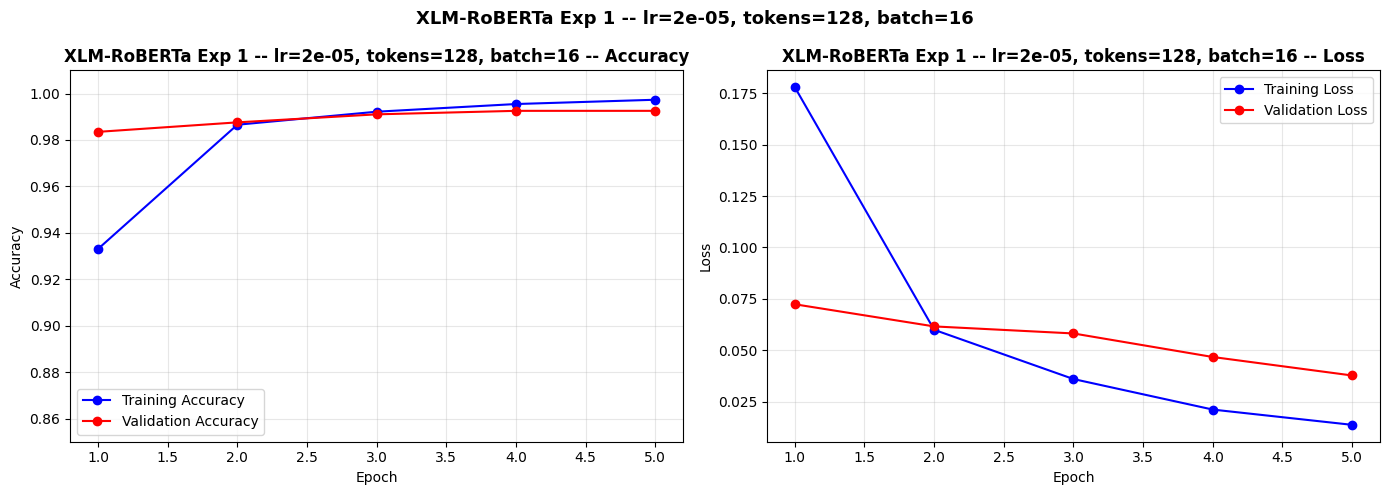

Saved: sweep_exp1_curves.png


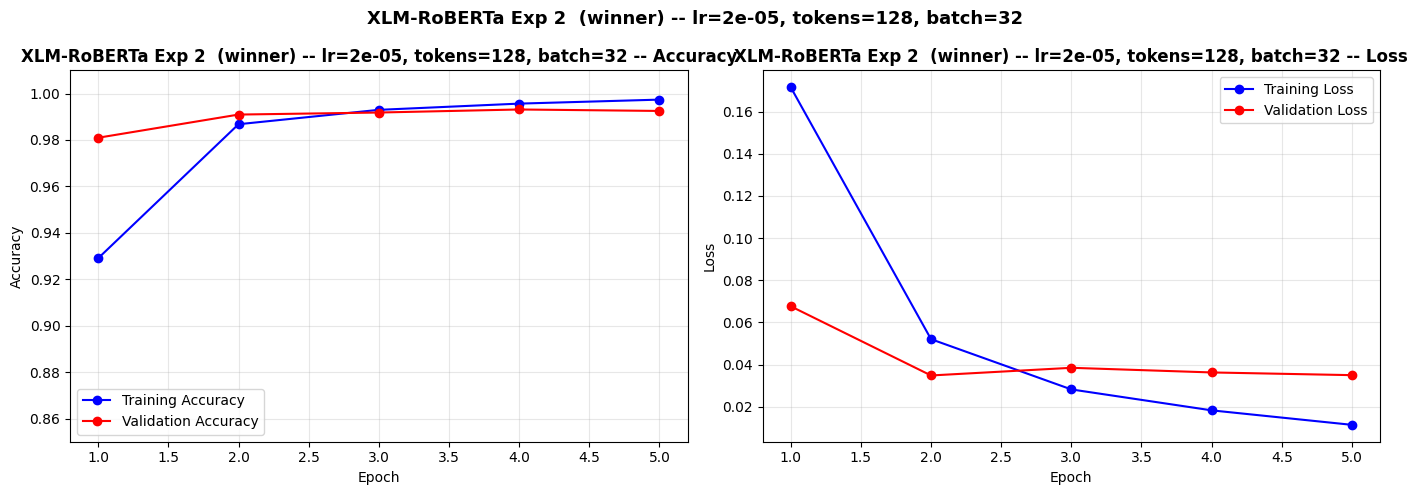

Saved: sweep_exp2_curves.png


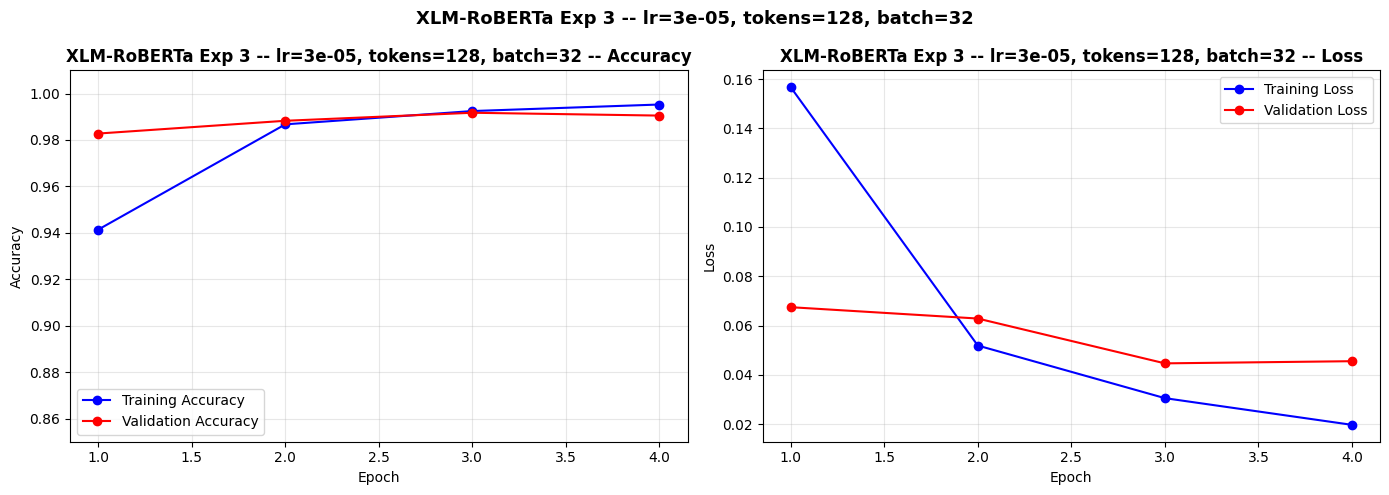

Saved: sweep_exp3_curves.png


In [11]:
# =============================================================================
# CELL 7c: Plot accuracy/loss curves for each of the 3 experiments
# -----------------------------------------------------------------------------
# If a config's checkpoint was loaded from disk instead of trained this session,
# there is no per-epoch history to plot -- skip that one with a short notice.
# =============================================================================
for cfg in sweep_configs:
    label = cfg['label']
    h = sweep_histories[label]
    if h is None:
        print(f"[{label}] Skipping training-curve plot -- loaded from checkpoint, no epoch history available.")
        continue
    suffix = '  (winner)' if label == best_sweep_label else ''
    plot_training_curves(
        h,
        title=f'XLM-RoBERTa {label}{suffix} -- lr={cfg["lr"]}, tokens={cfg["max_length"]}, batch={cfg["batch_size"]}',
        save_name=f'sweep_{label.lower().replace(" ", "")}_curves',
    )


In [12]:
# =============================================================================
# CELL 7d: Collect the per-experiment test results already computed in 7a
# -----------------------------------------------------------------------------
# train_or_load() already ran the test-set evaluation inside the Section 7a loop --
# this cell just repackages those results into the sweep_test_results dict that
# later cells (7e, Section 10) expect, with no need to reload any model.
# =============================================================================
sweep_test_results = {}

for cfg in sweep_configs:
    label = cfg['label']
    info  = sweep_checkpoints[label]
    sweep_test_results[label] = {
        'df': info['df_test'], 'true': info['test_true'],
        'pred': info['test_preds'], 'probs': info['test_probs'],
    }
    overall_f1 = info['df_test'][info['df_test']['language'] == 'overall']['f1'].values[0]
    print(f"{label:10s}  Test F1 = {overall_f1:.4f}")


Exp 1       Test F1 = 0.9917
Exp 2       Test F1 = 0.9929
Exp 3       Test F1 = 0.9912


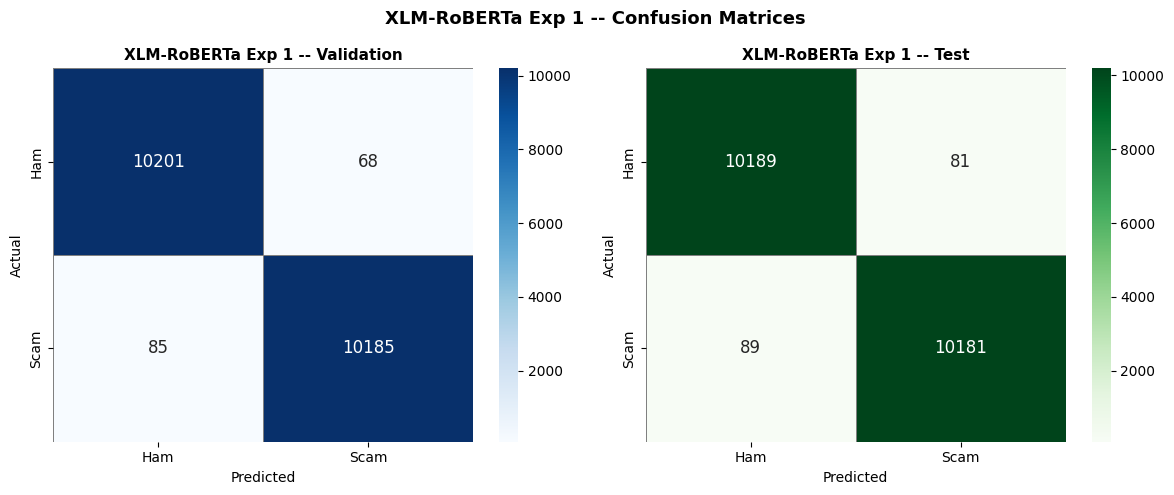

Saved: sweep_exp1_confusion.png


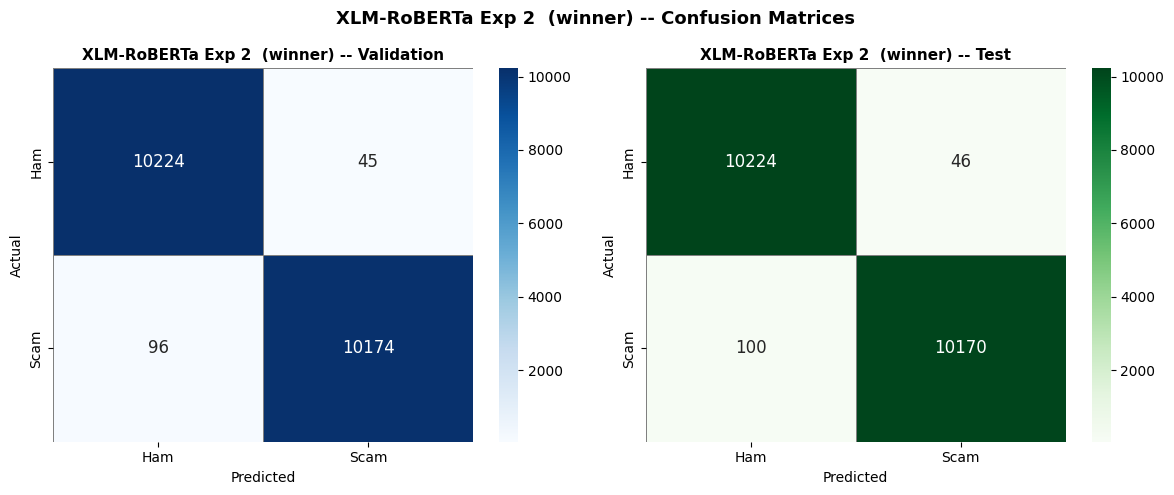

Saved: sweep_exp2_confusion.png


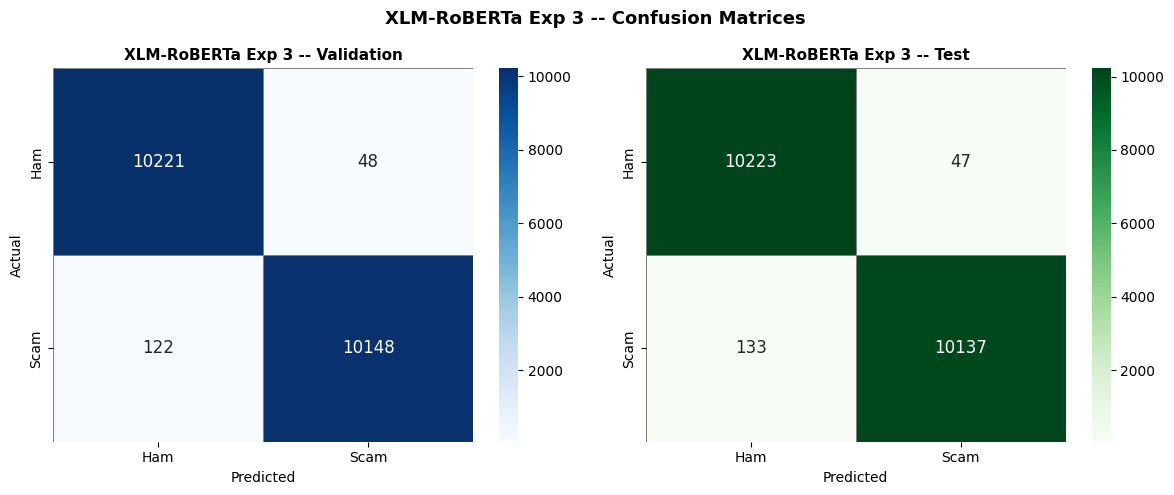

Saved: sweep_exp3_confusion.png


In [13]:
# =============================================================================
# CELL 7e: Confusion matrices for each of the 3 experiments
# -----------------------------------------------------------------------------
# Validation predictions were already computed inside train_or_load() in 7a and
# stored in sweep_checkpoints -- reused directly here, no reloading needed.
# =============================================================================
for cfg in sweep_configs:
    label = cfg['label']
    info  = sweep_checkpoints[label]
    res   = sweep_test_results[label]

    suffix = '  (winner)' if label == best_sweep_label else ''
    plot_confusion_matrices(
        info['val_true'], info['val_preds'], res['true'], res['pred'],
        title=f'XLM-RoBERTa {label}{suffix}',
        save_name=f'sweep_{label.lower().replace(" ", "")}_confusion',
    )


## 8. WeightedRandomSampler experiment

Addresses English dominance in the training set by upsampling minority languages during
training. Sample weights are inversely proportional to language frequency. Uses the
**winning configuration from Section 7** (not a separate sweep), so this experiment isolates
the effect of the sampling strategy alone.


In [14]:
# =============================================================================
# CELL 8: WeightedRandomSampler experiment (uses WINNING_CONFIG, checkpoint-aware)
# -----------------------------------------------------------------------------
from torch.utils.data import WeightedRandomSampler   # PyTorch sampler that can over-sample minority classes

print("="*65)
print(f"WEIGHTEDRANDOMSAMPLER EXPERIMENT  (using {best_sweep_label} config)")
print("="*65)

# -- Build one sample weight per training row, inversely proportional to how common
#    that row's language is (rare languages get sampled more often per epoch) --
lang_counts  = df_train['language'].value_counts().to_dict()
total_train  = len(df_train)
lang_weights = {lang: total_train / count for lang, count in lang_counts.items()}
sample_weights = df_train['language'].map(lang_weights).values

print("Language counts in training set:")
for lang, count in sorted(lang_counts.items()):
    print(f"  {lang:10s}: {count:,}  (weight = {lang_weights[lang]:.2f})")

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True   # replacement=True allows over-sampling
)

# Re-tokenise with the winning config's max_length/batch_size for a fair, apples-to-apples comparison
wrs_tokenizer = AutoTokenizer.from_pretrained(XLM_MODEL_NAME)
wrs_train_ds  = ScamSenseDataset(df_train, wrs_tokenizer, WINNING_CONFIG['max_length'])

wrs_train_loader = DataLoader(
    wrs_train_ds, batch_size=WINNING_CONFIG['batch_size'], sampler=sampler,   # sampler replaces shuffle=True here
    num_workers=2, pin_memory=True
)

# Val/test loaders for the winning config are already built and cached from the sweep -- reuse them
wrs_val_loader  = sweep_checkpoints[best_sweep_label]['val_loader']
wrs_test_loader = sweep_checkpoints[best_sweep_label]['test_loader']

print(f"\nWeightedRandomSampler train loader: {len(wrs_train_loader)} batches")
print(f"Training XLM-RoBERTa with winning config (lr={WINNING_CONFIG['lr']}, "
      f"tokens={WINNING_CONFIG['max_length']}, batch={WINNING_CONFIG['batch_size']})...")

wrs_model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
WRS_RUN   = 'xlmroberta-wrs'   # fixed run name -> also the checkpoint filename stem

result = train_or_load(
    model=wrs_model, model_name=XLM_MODEL_NAME, run_name=WRS_RUN, label='WRS',
    train_loader=wrs_train_loader, val_loader=wrs_val_loader, test_loader=wrs_test_loader,
    epochs=SWEEP_EPOCHS, lr=WINNING_CONFIG['lr'],
    batch_size=WINNING_CONFIG['batch_size'], max_length=WINNING_CONFIG['max_length'],
)

# Unpack everything the next two cells (8a, 8b) and Section 10 need
WRS_CKPT       = result['ckpt_path']
wrs_history    = result['history']
df_wrs_test    = result['df_test']
wrs_test_true  = result['test_true']
wrs_test_preds = result['test_preds']
wrs_test_probs = result['test_probs']
wrs_val_true   = result['val_true']
wrs_val_preds  = result['val_preds']

del wrs_model
torch.cuda.empty_cache()


WEIGHTEDRANDOMSAMPLER EXPERIMENT  (using Exp 2 config)
Language counts in training set:
  en        : 68,730  (weight = 1.39)
  ms        : 6,682  (weight = 14.34)
  singlish  : 7,000  (weight = 13.69)
  ta        : 6,492  (weight = 14.76)
  zh        : 6,947  (weight = 13.80)

WeightedRandomSampler train loader: 2996 batches
Training XLM-RoBERTa with winning config (lr=2e-05, tokens=128, batch=32)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable
[WRS] No checkpoint found -- training from scratch.

  MODEL : xlm-roberta-base
  RUN   : xlmroberta-wrs
  LR=2e-05 | Batch=32 | Epochs=10



  Ep1 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 1/10  [927s]
  Train Loss : 0.1204  |  Train Acc: 0.9506  |  Train F1: 0.9506
  Val Loss   : 0.0944  |  Val Acc:   0.9740  |  Val F1:   0.9740
  Precision  : 0.9740  |  Recall:    0.9740  |  LR:       2.00e-05
  Val F1 improved (-inf -> 0.9740) -- checkpoint saved



...

Epoch 7/10  [919s]
  Train Loss : 0.0068  |  Train Acc: 0.9985  |  Train F1: 0.9985
  Val Loss   : 0.0482  |  Val Acc:   0.9913  |  Val F1:   0.9913
  Precision  : 0.9914  |  Recall:    0.9913  |  LR:       6.67e-06
  Val F1 improved (0.9898 -> 0.9913) -- checkpoint saved



  Ep8 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 8/10  [918s]
  Train Loss : 0.0058  |  Train Acc: 0.9987  |  Train F1: 0.9987
  Val Loss   : 0.0453  |  Val Acc:   0.9924  |  Val F1:   0.9924
  Precision  : 0.9924  |  Recall:    0.9924  |  LR:       4.44e-06
  Val F1 improved (0.9913 -> 0.9924) -- checkpoint saved



  Ep9 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 9/10  [919s]
  Train Loss : 0.0045  |  Train Acc: 0.9990  |  Train F1: 0.9990
  Val Loss   : 0.0463  |  Val Acc:   0.9919  |  Val F1:   0.9919
  Precision  : 0.9919  |  Recall:    0.9919  |  LR:       2.22e-06
  Val F1 did not improve (0.9924). No-improve streak: 1/1

  Early stopping triggered at epoch 9. Restoring best weights.
🏃 View run xlmroberta-wrs at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/1387e76ffff949e1bf7160d74b8b9a88
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9924
  Checkpoint: /kaggle/working/models/xlmroberta-wrs_best.pt

  xlmroberta-wrs -- Test Results
  Loss      : 0.0476
  Accuracy  : 0.9925  (99.25%)
  Precision : 0.9925
  Recall    : 0.9925
  F1-Score  : 0.9925
  AUC-ROC   : 0.9983

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99     10270
        Scam       0.99      0.99 

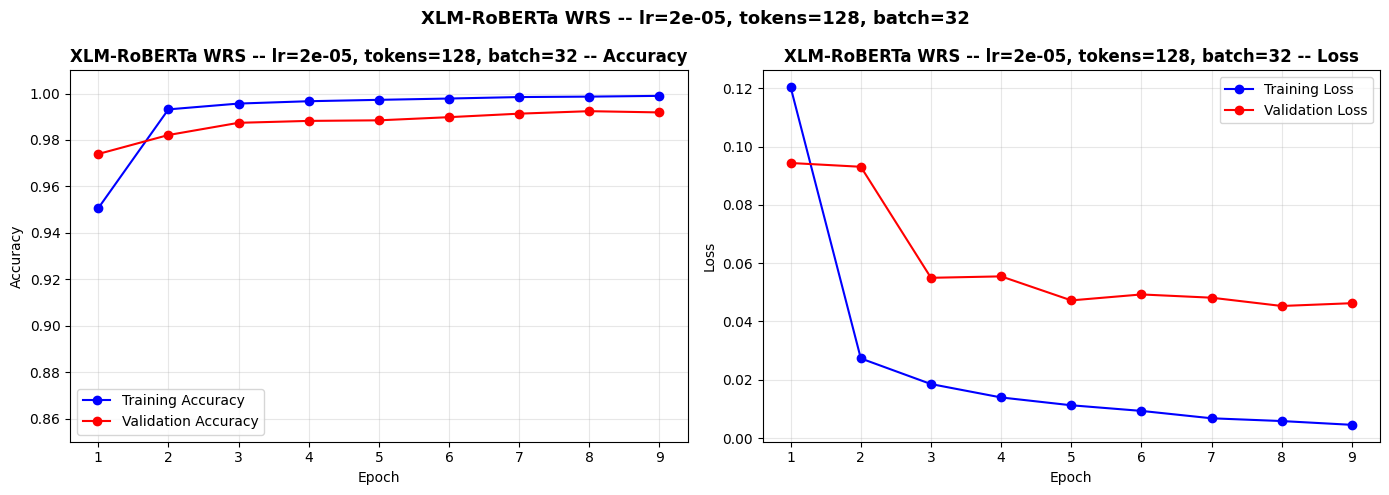

Saved: wrs_curves.png


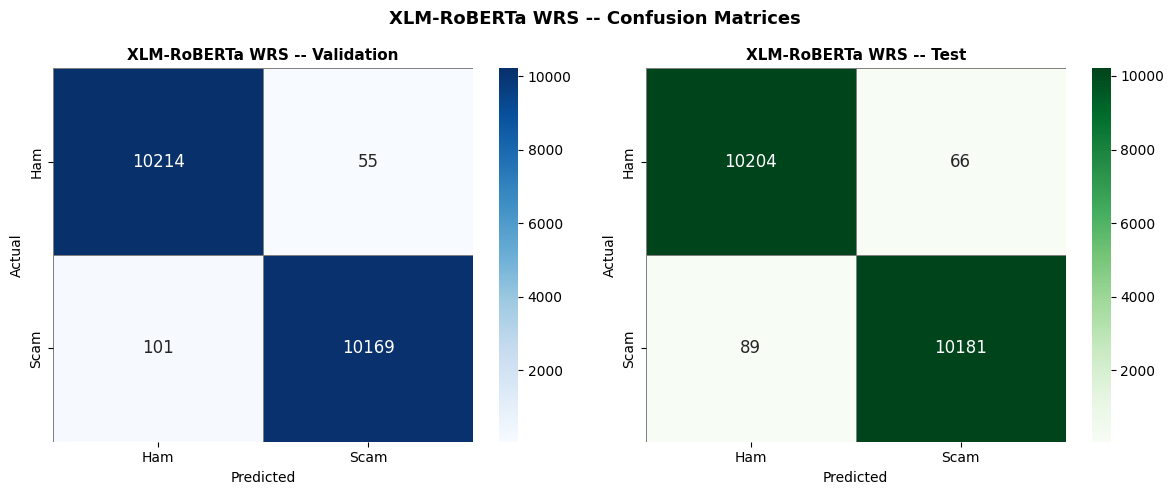

Saved: wrs_confusion.png


In [15]:
# =============================================================================
# CELL 8a: WRS -- training curves and confusion matrix
# -----------------------------------------------------------------------------
# If WRS was loaded from an existing checkpoint this session (no fresh training),
# there is no epoch history to plot -- the curve plot is skipped in that case.
# =============================================================================
if wrs_history is not None:
    plot_training_curves(
        wrs_history,
        title=f'XLM-RoBERTa WRS -- lr={WINNING_CONFIG["lr"]}, tokens={WINNING_CONFIG["max_length"]}, batch={WINNING_CONFIG["batch_size"]}',
        save_name='wrs_curves',
    )
else:
    print("Skipping training-curve plot -- WRS loaded from checkpoint, no epoch history available.")

plot_confusion_matrices(
    wrs_val_true, wrs_val_preds, wrs_test_true, wrs_test_preds,
    title='XLM-RoBERTa WRS', save_name='wrs_confusion',
)


In [16]:
# =============================================================================
# CELL 8b: WRS vs the winning sweep config -- per-language F1 comparison
# -----------------------------------------------------------------------------
df_winner_test = sweep_test_results[best_sweep_label]['df']   # the winning sweep config's per-language test results
df_winner_lang = df_winner_test[df_winner_test['language'] != 'overall'][['language', 'f1']].rename(
    columns={'f1': f'f1_{best_sweep_label.lower().replace(" ", "")}'})
df_wrs_lang = df_wrs_test[df_wrs_test['language'] != 'overall'][['language', 'f1']].rename(columns={'f1': 'f1_wrs'})

comparison_wrs = df_winner_lang.merge(df_wrs_lang, on='language')   # join on language so rows line up
winner_col = f'f1_{best_sweep_label.lower().replace(" ", "")}'
comparison_wrs['delta'] = (comparison_wrs['f1_wrs'] - comparison_wrs[winner_col]).round(4)   # positive = WRS helped

print(f"\n=== WeightedRandomSampler vs {best_sweep_label} (winning config, no sampling change) ===\n")
print(comparison_wrs.to_string(index=False))
comparison_wrs.to_csv(f'{OUTPUT_DIR}/wrs_vs_winner.csv', index=False)
print(f"\nSaved: wrs_vs_winner.csv")

winner_overall = df_winner_test[df_winner_test['language'] == 'overall']['f1'].values[0]
wrs_overall    = df_wrs_test[df_wrs_test['language'] == 'overall']['f1'].values[0]
print(f"\nOverall F1 -- {best_sweep_label}: {winner_overall:.4f}  |  WRS: {wrs_overall:.4f}  "
      f"|  Delta: {wrs_overall - winner_overall:+.4f}")



=== WeightedRandomSampler vs Exp 2 (winning config, no sampling change) ===

language  f1_exp2  f1_wrs   delta
      en   0.9904  0.9898 -0.0006
      ms   1.0000  1.0000  0.0000
singlish   0.9987  0.9980 -0.0007
      ta   0.9978  0.9986  0.0008
      zh   1.0000  1.0000  0.0000

Saved: wrs_vs_winner.csv

Overall F1 -- Exp 2: 0.9929  |  WRS: 0.9925  |  Delta: -0.0004


## 9. Text normalisation experiment

Tests whether normalising text (URL -> `[URL]`, amount -> `[AMOUNT]`, emoji removal -- applied
in NB02 Section 2.8) improves F1 relative to raw text. Uses the **same winning configuration**
from Section 7, so only the preprocessing strategy is varied.


In [17]:
# =============================================================================
# CELL 9: Text normalisation experiment (uses WINNING_CONFIG, checkpoint-aware)
# =============================================================================
print("="*65)
print(f"TEXT NORMALISATION EXPERIMENT  (using {best_sweep_label} config)")
print("="*65)

def load_norm_split(filename):
    # Same read-either-location pattern as load_split() in Section 3
    kaggle_path  = f'{INPUT_DIR}/{filename}'
    working_path = f'{OUTPUT_DIR}/{filename}'
    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path, encoding='utf-8-sig')
    elif os.path.exists(working_path):
        return pd.read_csv(working_path, encoding='utf-8-sig')
    else:
        raise FileNotFoundError(f'{filename} not found. Run NB02 Section 2.8 first.')

# The normalised splits are separate CSVs (URLs/amounts replaced with placeholder tokens, see NB02)
df_train_norm = load_norm_split('train_norm.csv').dropna(subset=['text']).reset_index(drop=True)
df_val_norm   = load_norm_split('val_norm.csv').dropna(subset=['text']).reset_index(drop=True)
df_test_norm  = load_norm_split('test_norm.csv').dropna(subset=['text']).reset_index(drop=True)

print(f"Normalised splits loaded: train={len(df_train_norm):,} | val={len(df_val_norm):,} | test={len(df_test_norm):,}")

# Tokenise the normalised text at the winning config's settings
norm_tokenizer, norm_train_loader, norm_val_loader, norm_test_loader = build_loaders(
    XLM_MODEL_NAME,
    max_length=WINNING_CONFIG['max_length'],
    batch_size=WINNING_CONFIG['batch_size'],
    train_df=df_train_norm, val_df=df_val_norm, test_df=df_test_norm,
)

print(f"Training XLM-RoBERTa on normalised dataset with winning config "
      f"(lr={WINNING_CONFIG['lr']}, tokens={WINNING_CONFIG['max_length']}, batch={WINNING_CONFIG['batch_size']})...")

norm_model = build_model(XLM_MODEL_NAME, freeze_encoder=False)
NORM_RUN   = 'xlmroberta-normalised'

result = train_or_load(
    model=norm_model, model_name=XLM_MODEL_NAME, run_name=NORM_RUN, label='Text-Norm',
    train_loader=norm_train_loader, val_loader=norm_val_loader, test_loader=norm_test_loader,
    epochs=SWEEP_EPOCHS, lr=WINNING_CONFIG['lr'],
    batch_size=WINNING_CONFIG['batch_size'], max_length=WINNING_CONFIG['max_length'],
)

# Unpack everything the next two cells (9a, 9b) and Section 10 need
NORM_CKPT       = result['ckpt_path']
norm_history    = result['history']
df_norm_test    = result['df_test']
norm_test_true  = result['test_true']
norm_test_preds = result['test_preds']
norm_test_probs = result['test_probs']
norm_val_true   = result['val_true']
norm_val_preds  = result['val_preds']

del norm_model
torch.cuda.empty_cache()


TEXT NORMALISATION EXPERIMENT  (using Exp 2 config)
Normalised splits loaded: train=95,851 | val=20,539 | test=20,540
Tokenising with xlm-roberta-base  (max_length=128, batch_size=32)...
Loaders ready: 2996 train batches
Training XLM-RoBERTa on normalised dataset with winning config (lr=2e-05, tokens=128, batch=32)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable
[Text-Norm] No checkpoint found -- training from scratch.

  MODEL : xlm-roberta-base
  RUN   : xlmroberta-normalised
  LR=2e-05 | Batch=32 | Epochs=10



  Ep1 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 1/10  [941s]
  Train Loss : 0.1830  |  Train Acc: 0.9253  |  Train F1: 0.9253
  Val Loss   : 0.0500  |  Val Acc:   0.9871  |  Val F1:   0.9871
  Precision  : 0.9871  |  Recall:    0.9871  |  LR:       2.00e-05
  Val F1 improved (-inf -> 0.9871) -- checkpoint saved



  Ep2 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 2/10  [933s]
  Train Loss : 0.0526  |  Train Acc: 0.9862  |  Train F1: 0.9862
  Val Loss   : 0.0554  |  Val Acc:   0.9845  |  Val F1:   0.9845
  Precision  : 0.9849  |  Recall:    0.9845  |  LR:       1.78e-05
  Val F1 did not improve (0.9871). No-improve streak: 1/1

  Early stopping triggered at epoch 2. Restoring best weights.
🏃 View run xlmroberta-normalised at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/b2d4c08f5f8641aa99bfc611ebf73740
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9871
  Checkpoint: /kaggle/working/models/xlmroberta-normalised_best.pt

  xlmroberta-normalised -- Test Results
  Loss      : 0.0511
  Accuracy  : 0.9858  (98.58%)
  Precision : 0.9858
  Recall    : 0.9858
  F1-Score  : 0.9858
  AUC-ROC   : 0.9980

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99     10270
        Scam 

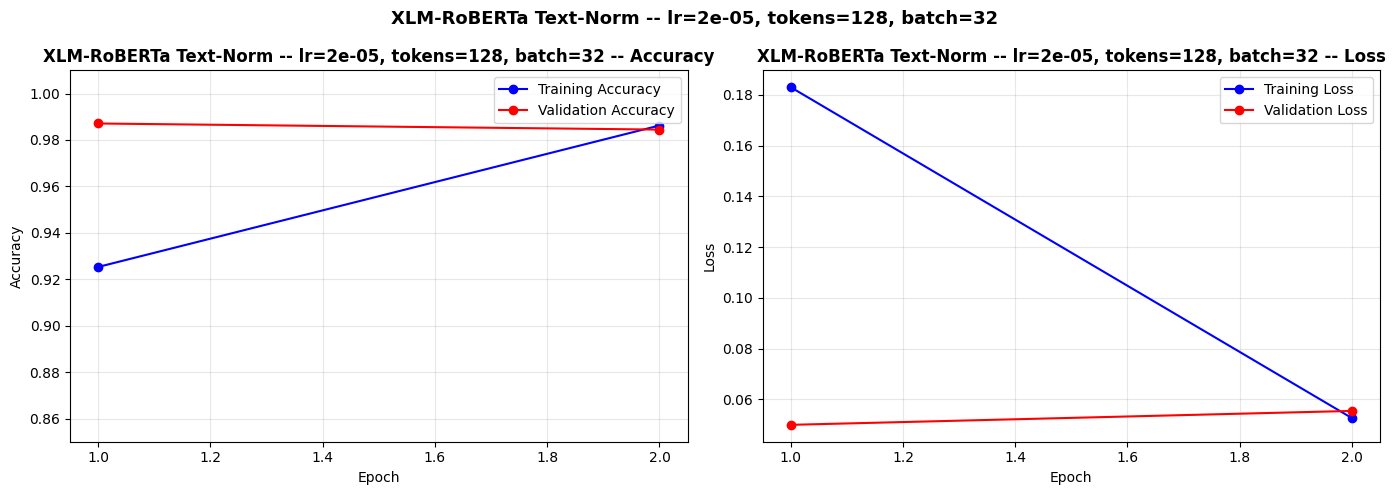

Saved: textnorm_curves.png


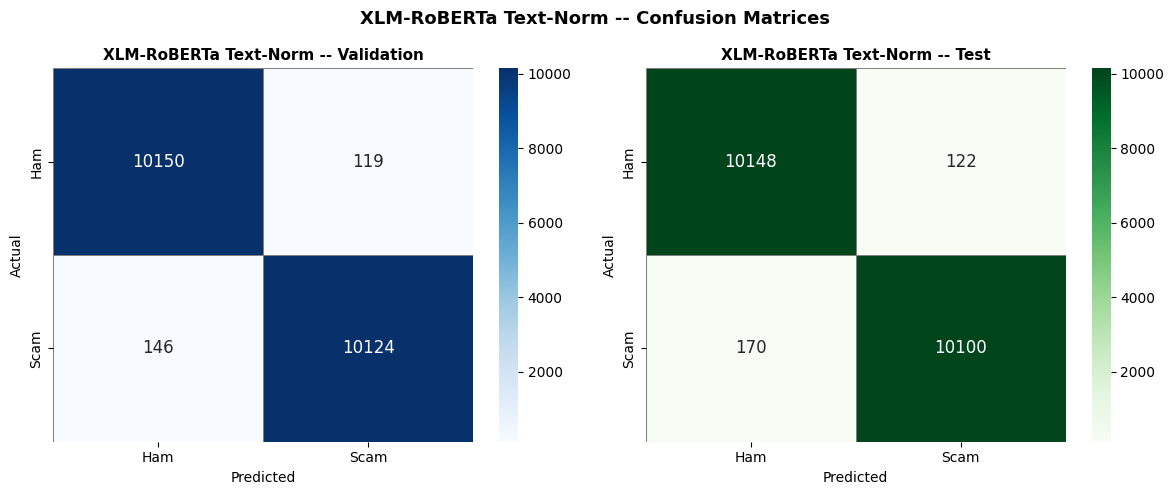

Saved: textnorm_confusion.png


In [18]:
# =============================================================================
# CELL 9a: Text-normalisation -- training curves and confusion matrix
# -----------------------------------------------------------------------------
# Skips the curve plot if Text-Norm was loaded from checkpoint (no epoch history).
# =============================================================================
if norm_history is not None:
    plot_training_curves(
        norm_history,
        title=f'XLM-RoBERTa Text-Norm -- lr={WINNING_CONFIG["lr"]}, tokens={WINNING_CONFIG["max_length"]}, batch={WINNING_CONFIG["batch_size"]}',
        save_name='textnorm_curves',
    )
else:
    print("Skipping training-curve plot -- Text-Norm loaded from checkpoint, no epoch history available.")

plot_confusion_matrices(
    norm_val_true, norm_val_preds, norm_test_true, norm_test_preds,
    title='XLM-RoBERTa Text-Norm', save_name='textnorm_confusion',
)


In [19]:
# =============================================================================
# CELL 9b: Raw (winning config) vs Normalised -- per-language F1 comparison
# =============================================================================
df_raw_lang  = df_winner_test[df_winner_test['language'] != 'overall'][['language', 'f1']].rename(columns={'f1': 'f1_raw'})
df_norm_lang = df_norm_test[df_norm_test['language'] != 'overall'][['language', 'f1']].rename(columns={'f1': 'f1_norm'})

comparison_norm = df_raw_lang.merge(df_norm_lang, on='language')
comparison_norm['delta'] = (comparison_norm['f1_norm'] - comparison_norm['f1_raw']).round(4)   # positive = normalisation helped

raw_overall  = winner_overall   # already computed in Cell 8b
norm_overall = df_norm_test[df_norm_test['language'] == 'overall']['f1'].values[0]

print("\n=== Raw (winning config) vs Normalised -- Per-Language F1 ===")
print(comparison_norm.to_string(index=False))
print(f"\nOverall F1 -- Raw: {raw_overall:.4f}  |  Normalised: {norm_overall:.4f}  "
      f"|  Delta: {norm_overall - raw_overall:+.4f}")
comparison_norm.to_csv(f'{OUTPUT_DIR}/normalised_vs_raw.csv', index=False)
print(f"Saved: normalised_vs_raw.csv")



=== Raw (winning config) vs Normalised -- Per-Language F1 ===
language  f1_raw  f1_norm   delta
      en  0.9904   0.9805 -0.0099
      ms  1.0000   0.9993 -0.0007
singlish  0.9987   0.9973 -0.0014
      ta  0.9978   1.0000  0.0022
      zh  1.0000   1.0000  0.0000

Overall F1 -- Raw: 0.9929  |  Normalised: 0.9858  |  Delta: -0.0071
Saved: normalised_vs_raw.csv


## 10. Consolidated XLM-RoBERTa comparison -- all 5 variants

Combines Exp 1-3, WRS, and Text-Norm into a single results table and a single F1-per-language
bar chart, so the full set of XLM-RoBERTa experiments can be read at a glance.


In [20]:
# =============================================================================
# CELL 10: Combine all 5 XLM-RoBERTa variants into one table + one chart
# -----------------------------------------------------------------------------
all_xlm_dfs = []
for cfg in sweep_configs:                       # Exp 1, Exp 2, Exp 3
    label = cfg['label']
    df_e = sweep_test_results[label]['df'].copy()
    df_e['experiment'] = label
    all_xlm_dfs.append(df_e)

all_xlm_dfs.append(df_wrs_test.copy())          # WRS
all_xlm_dfs.append(df_norm_test.copy())         # Text-Norm

df_xlm_all = pd.concat(all_xlm_dfs, ignore_index=True)   # one long table, all 5 XLM variants stacked
df_xlm_all.to_csv(f'{OUTPUT_DIR}/xlmroberta_all_experiments.csv', index=False)

print("All 5 XLM-RoBERTa experiments -- overall metrics:")
print(df_xlm_all[df_xlm_all['language'] == 'overall'][['experiment', 'accuracy', 'precision', 'recall', 'f1', 'auc']]
      .sort_values('f1', ascending=False).to_string(index=False))
print(f"\nSaved: xlmroberta_all_experiments.csv")


All 5 XLM-RoBERTa experiments -- overall metrics:
experiment  accuracy  precision  recall     f1    auc
     Exp 2    0.9929     0.9929  0.9929 0.9929 0.9990
       WRS    0.9925     0.9925  0.9925 0.9925 0.9983
     Exp 1    0.9917     0.9917  0.9917 0.9917 0.9982
     Exp 3    0.9912     0.9913  0.9912 0.9912 0.9978
 Text-Norm    0.9858     0.9858  0.9858 0.9858 0.9980

Saved: xlmroberta_all_experiments.csv


## 11. mBERT baseline (trained once)

mBERT is trained **once**, as a frozen-encoder baseline, using the **token length and batch
size** from the winning XLM-RoBERTa configuration (Section 7) for a fair, consistent input
representation across both architectures.

The learning rate is kept separate from the XLM-RoBERTa winner: mBERT here uses a **frozen
encoder** (only the classification head is trainable), and frozen heads typically need a much
higher learning rate to converge in a small number of epochs than a fully fine-tuned encoder
does. Reusing the XLM-RoBERTa winner's lr (e.g. 1e-5 to 3e-5) would almost certainly
under-train the head. `MBERT_LR = 1e-3` is used instead, consistent with standard practice for
frozen-encoder linear-probe baselines.


In [21]:
# =============================================================================
# CELL 11: Build and train mBERT (frozen baseline, checkpoint-aware)
# =============================================================================
MBERT_MODEL_NAME = 'bert-base-multilingual-cased'
MBERT_RUN_NAME    = 'mbert-scamsense-baseline'
MBERT_LR          = 1e-3  # frozen encoder needs a higher lr than full fine-tune; see Section 11 markdown note

# Tokenise at the winning config's token length/batch size, for a fair comparison with XLM-RoBERTa
mbert_tokenizer, mbert_train_loader, mbert_val_loader, mbert_test_loader = build_loaders(
    MBERT_MODEL_NAME,
    max_length=WINNING_CONFIG['max_length'],
    batch_size=WINNING_CONFIG['batch_size'],
)

mbert_model = build_model(MBERT_MODEL_NAME, freeze_encoder=True)   # freeze_encoder=True -> only the head trains
total_params     = sum(p.numel() for p in mbert_model.parameters())
trainable_params = sum(p.numel() for p in mbert_model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.3f}%)")
print(f"Token length / batch reused from winning config ({best_sweep_label}): "
      f"{WINNING_CONFIG['max_length']} tokens, batch {WINNING_CONFIG['batch_size']}")
print(f"Track at: https://dagshub.com/Bhoovika/ScamSense.mlflow\n")

result = train_or_load(
    model=mbert_model, model_name=MBERT_MODEL_NAME, run_name=MBERT_RUN_NAME, label='mBERT',
    train_loader=mbert_train_loader, val_loader=mbert_val_loader, test_loader=mbert_test_loader,
    epochs=SWEEP_EPOCHS, lr=MBERT_LR, freeze_encoder=True,
    batch_size=WINNING_CONFIG['batch_size'], max_length=WINNING_CONFIG['max_length'],
)

# Unpack everything the next two cells (11a, 11c) need
MBERT_CKPT       = result['ckpt_path']
mbert_history    = result['history']
df_mbert_test    = result['df_test']
mbert_test_true  = result['test_true']
mbert_test_preds = result['test_preds']
mbert_test_probs = result['test_probs']
mbert_val_true   = result['val_true']
mbert_val_preds  = result['val_preds']


Tokenising with bert-base-multilingual-cased  (max_length=128, batch_size=32)...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 1/10  [251s]
  Train Loss : 0.3572  |  Train Acc: 0.8393  |  Train F1: 0.8393
  Val Loss   : 0.2298  |  Val Acc:   0.9076  |  Val F1:   0.9076
  Precision  : 0.9078  |  Recall:    0.9076  |  LR:       1.00e-03
  Val F1 improved (-inf -> 0.9076) -- checkpoint saved



  Ep2 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 2/10  [250s]
  Train Loss : 0.2488  |  Train Acc: 0.8955  |  Train F1: 0.8955
  Val Loss   : 0.1831  |  Val Acc:   0.9303  |  Val F1:   0.9303
  Precision  : 0.9308  |  Recall:    0.9303  |  LR:       8.89e-04
  Val F1 improved (0.9076 -> 0.9303) -- checkpoint saved



  Ep3 train:   0%|                                  | 0/2996 [00:00<?, ?batch/s]

Epoch 3/10  [250s]
  Train Loss : 0.2161  |  Train Acc: 0.9112  |  Train F1: 0.9112
  Val Loss   : 0.1775  |  Val Acc:   0.9272  |  Val F1:   0.9271
  Precision  : 0.9293  |  Recall:    0.9272  |  LR:       7.78e-04
  Val F1 did not improve (0.9303). No-improve streak: 1/1

  Early stopping triggered at epoch 3. Restoring best weights.
🏃 View run mbert-scamsense-baseline at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0/runs/7b8426a3bbde464ea74ced04b6c89a9c
🧪 View experiment at: https://dagshub.com/Bhoovika/ScamSense.mlflow/#/experiments/0
  Training complete -- Best Val F1: 0.9303
  Checkpoint: /kaggle/working/models/mbert-scamsense-baseline_best.pt

  mbert-scamsense-baseline -- Test Results
  Loss      : 0.1828
  Accuracy  : 0.9282  (92.82%)
  Precision : 0.9286
  Recall    : 0.9282
  F1-Score  : 0.9282
  AUC-ROC   : 0.9804

Classification Report (Test):

              precision    recall  f1-score   support

         Ham       0.94      0.91      0.93     10270
    

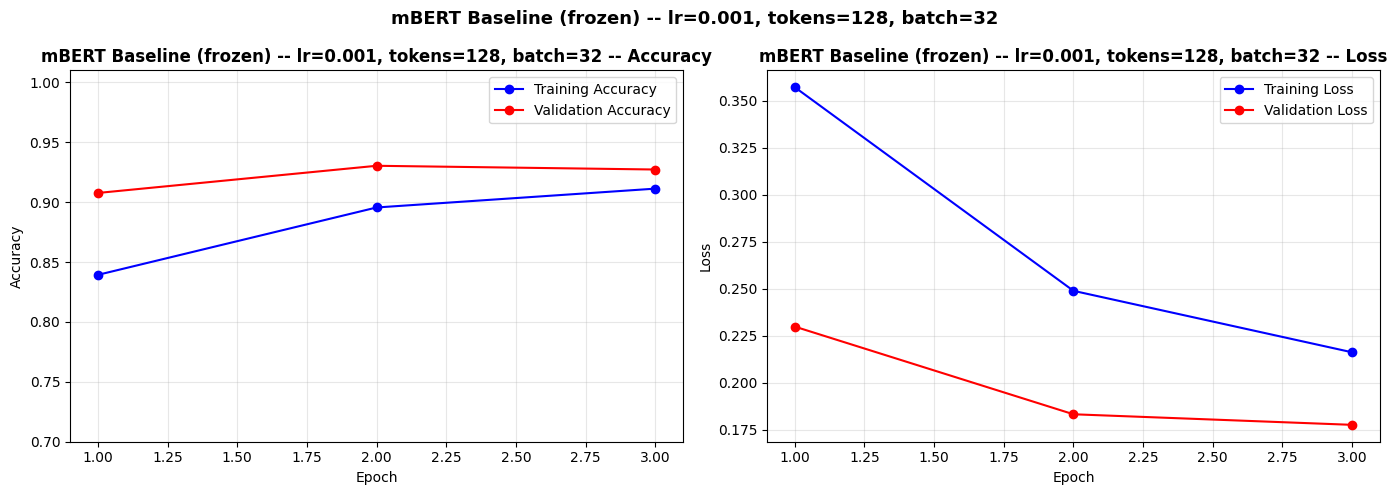

Saved: mbert_curves.png


In [22]:
# =============================================================================
# CELL 11a: mBERT -- training curves
# -----------------------------------------------------------------------------
# Skips the plot if mBERT was loaded from checkpoint (no epoch history available).
# =============================================================================
if mbert_history is not None:
    plot_training_curves(
        mbert_history,
        title=f'mBERT Baseline (frozen) -- lr={MBERT_LR}, tokens={WINNING_CONFIG["max_length"]}, batch={WINNING_CONFIG["batch_size"]}',
        save_name='mbert_curves', acc_ylim=(0.7, 1.01),
    )
else:
    print("Skipping training-curve plot -- mBERT loaded from checkpoint, no epoch history available.")


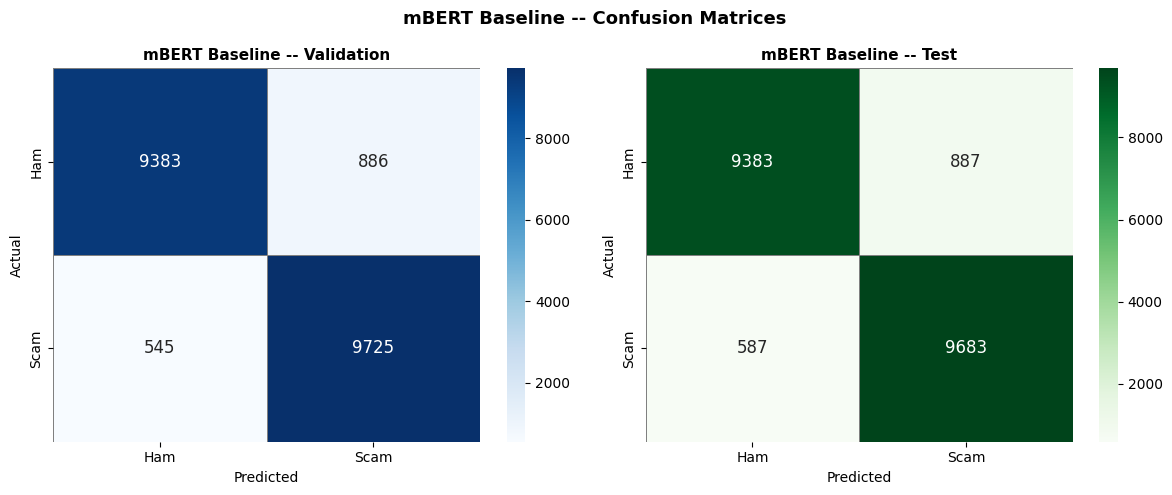

Saved: mbert_confusion.png


In [23]:
# =============================================================================
# CELL 11c: mBERT -- confusion matrices
# =============================================================================
plot_confusion_matrices(
    mbert_val_true, mbert_val_preds, mbert_test_true, mbert_test_preds,
    title='mBERT Baseline', save_name='mbert_confusion',
)


## 12. Final comparison: best XLM-RoBERTa vs mBERT

Compares the single best XLM-RoBERTa variant (selected from all 5 experiments in Section 10)
against the mBERT baseline, and selects the overall best model for export.


Best XLM-RoBERTa variant (by test F1): Exp 2  (F1 = 0.9929)
Overall best model: XLM-RoBERTa (Exp 2)  (F1 = 0.9929)


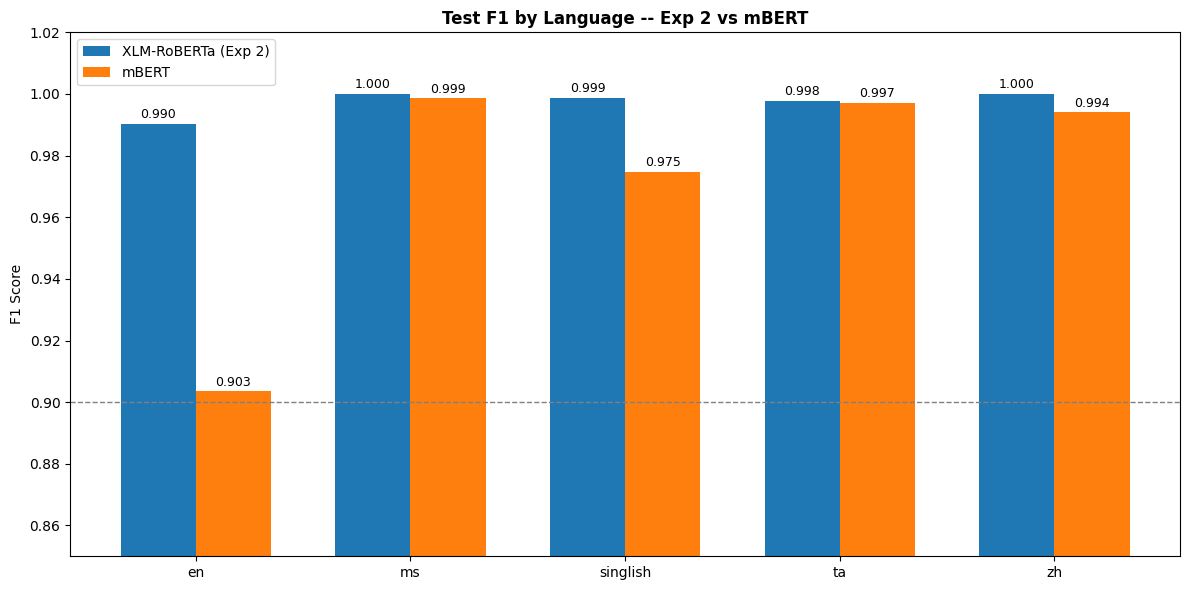

Saved: best_model_vs_mbert_by_language.png
Saved: final_comparison_best_vs_mbert.csv


In [10]:
# =============================================================================
# CELL 12: Best XLM-RoBERTa variant vs mBERT -- final model selection
# =============================================================================
import matplotlib.pyplot as plt
df_experiment_summary = pd.read_csv(ALL_SUMMARY_CSV)     # scalar metrics for all 6 experiments
df_all_perlang         = pd.read_csv(ALL_PERLANG_CSV)     # per-language test metrics for all 6 experiments

# -- Best XLM-RoBERTa variant, chosen by TEST F1 --
xlm_summary         = df_experiment_summary[df_experiment_summary['experiment'] != 'mBERT']
best_xlm_experiment = xlm_summary.loc[xlm_summary['test_f1'].idxmax(), 'experiment']
best_xlm_f1         = xlm_summary['test_f1'].max()

# -- Pull the winning XLM variant's and mBERT's per-language rows out of the combined table --
df_best_xlm = df_all_perlang[df_all_perlang['experiment'] == best_xlm_experiment].copy()
df_best_xlm['model'] = f'XLM-RoBERTa ({best_xlm_experiment})'

df_mbert_labelled = df_all_perlang[df_all_perlang['experiment'] == 'mBERT'].copy()
df_mbert_labelled['model'] = 'mBERT'

df_all = pd.concat([df_best_xlm, df_mbert_labelled], ignore_index=True)

# -- Overall best model between just these two candidates --
df_overall      = df_all[df_all['language'] == 'overall']
best_model_name = df_overall.loc[df_overall['f1'].idxmax(), 'model']
best_f1         = df_overall['f1'].max()

print(f"Best XLM-RoBERTa variant (by test F1): {best_xlm_experiment}  (F1 = {best_xlm_f1:.4f})")
print(f"Overall best model: {best_model_name}  (F1 = {best_f1:.4f})")

# -- Per-language F1 bar chart: best XLM variant vs mBERT --
df_by_lang = df_all[df_all['language'] != 'overall']          # drop the 'overall' row, keep per-language rows
languages  = sorted(df_by_lang['language'].unique())
x = np.arange(len(languages))                                  # one x position per language
width = 0.35                                                    # width of each model's bar

fig, ax = plt.subplots(figsize=(12, 6))
for offset, model in zip([-width/2, width/2], df_all['model'].unique()):   # side-by-side bars per model
    vals = [df_by_lang[(df_by_lang['language'] == lang) & (df_by_lang['model'] == model)]['f1'].values[0]
            for lang in languages]
    bars = ax.bar(x + offset, vals, width, label=model)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=9)      # print the F1 value above each bar

ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.set_ylabel('F1 Score')
ax.set_ylim(0.85, 1.02)
ax.set_title(f'Test F1 by Language -- {best_xlm_experiment} vs mBERT', fontweight='bold')
ax.axhline(0.90, color='gray', linestyle='--', linewidth=1)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/best_model_vs_mbert_by_language.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: best_model_vs_mbert_by_language.png')

df_all.to_csv(f'{OUTPUT_DIR}/final_comparison_best_vs_mbert.csv', index=False)
print('Saved: final_comparison_best_vs_mbert.csv')

## 12a. ROC / Precision-Recall curves

Plots the ROC curve and the Precision-Recall curve side by side, on the test set, for the
two most relevant models: the best XLM-RoBERTa variant from Section 12 (Exp 2) and the
mBERT baseline. Each curve is shaded against its corresponding reference line (the random-
classifier diagonal for ROC, the random-classifier baseline for Precision-Recall) so the
gain over chance is easy to see at a glance.


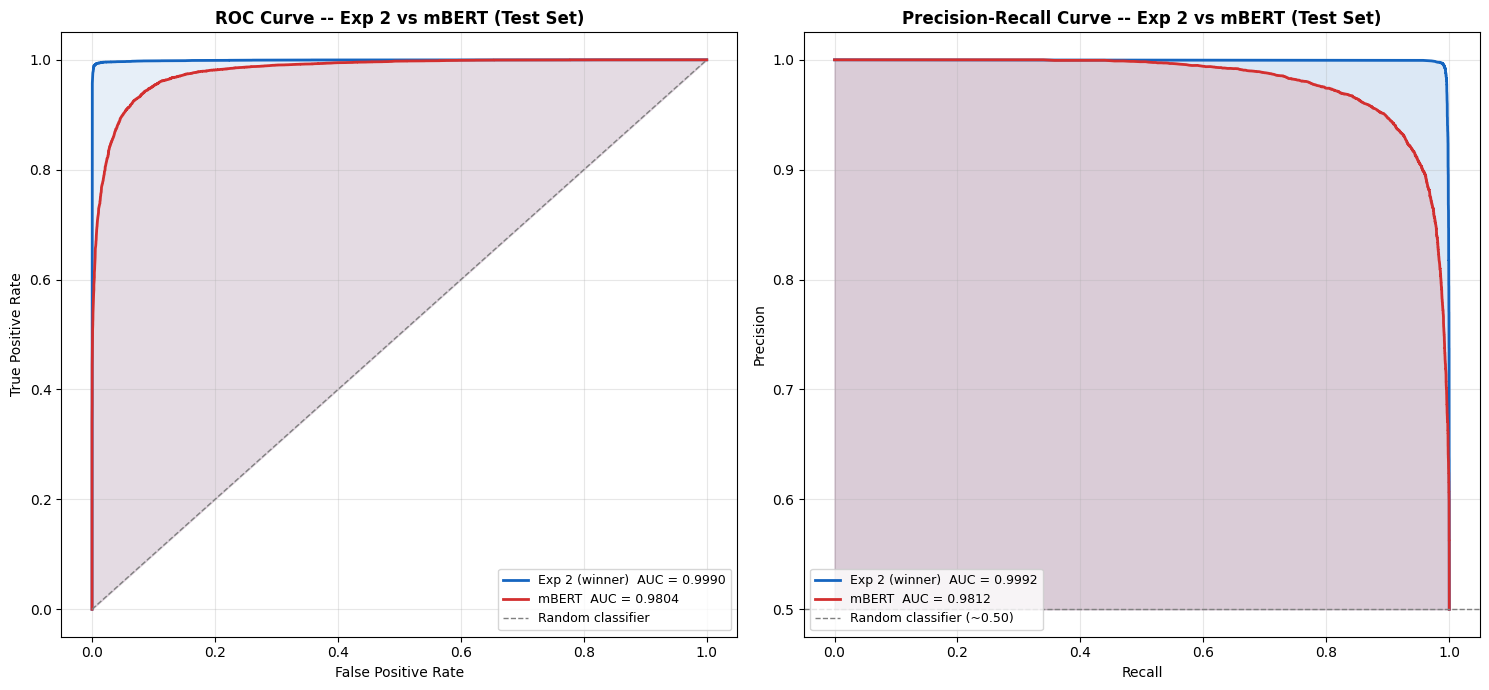

Saved: roc_pr_curves_exp2_vs_mbert.png


In [17]:
# =============================================================================
# CELL 12a: ROC + PR curves, side by side -- Exp 2 vs mBERT only (test set)
# -----------------------------------------------------------------------------
# Reads the per-example true labels / predicted probabilities logged by
# train_or_load() in Sections 7-11 -- no model reloading or re-inference needed.
# =============================================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve

df_test_predictions = pd.read_csv(ALL_PREDICTIONS_CSV)

# -- keep only the two models we care about --
models_to_plot = ['Exp 2', 'mBERT']
df_test_predictions = df_test_predictions[df_test_predictions['experiment'].isin(models_to_plot)]

colors = {
    'Exp 2': '#1565C0',   # Medium Blue
    'mBERT': '#D32F2F',   # Dark Red
}
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# -- ROC curve (left) --
ax = axes[0]
for label, grp in df_test_predictions.groupby('experiment'):
    fpr, tpr, _ = roc_curve(grp['true_label'], grp['pred_prob'])
    auc_val = auc(fpr, tpr)
    display_label = f'{label} (winner)' if label == best_xlm_experiment else label
    ax.plot(fpr, tpr, color=colors.get(label, '#999999'), lw=2,
            label=f'{display_label}  AUC = {auc_val:.4f}')
    # -- shade the area between this model's curve and the random-classifier diagonal --
    ax.fill_between(fpr, tpr, fpr, color=colors.get(label, '#999999'), alpha=0.10)

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random classifier')   # reference diagonal
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve -- Exp 2 vs mBERT (Test Set)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# -- Precision-Recall curve (right) --
ax = axes[1]
baseline = df_test_predictions.groupby('experiment')['true_label'].mean().mean()   # random-classifier reference line

for label, grp in df_test_predictions.groupby('experiment'):
    prec, rec, _ = precision_recall_curve(grp['true_label'], grp['pred_prob'])
    pr_auc = auc(rec, prec)
    display_label = f'{label} (winner)' if label == best_xlm_experiment else label
    ax.plot(rec, prec, color=colors.get(label, '#999999'), lw=2,
            label=f'{display_label}  AUC = {pr_auc:.4f}')
    # -- shade the area between this model's curve and the random-classifier baseline --
    ax.fill_between(rec, prec, baseline, where=(prec >= baseline),
                     color=colors.get(label, '#999999'), alpha=0.15)

ax.axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Random classifier (~{baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve -- Exp 2 vs mBERT (Test Set)', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_pr_curves_exp2_vs_mbert.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_pr_curves_exp2_vs_mbert.png')

## 12b. Summary comparison -- all experiments, one chart

A single scatter/dot chart summarising every experiment run in this notebook (3-config
sweep, WRS, text-norm, mBERT) on four key metrics at once -- accuracy, F1, precision, and
recall -- shown separately for the validation and test splits, and for all six models
alongside a zoomed-in view of the five XLM-RoBERTa variants only. This lets every result be
read at a glance instead of scrolling through individual sections.


Summary table (also saved as summary_comparison_all_experiments.csv):
experiment  val_accuracy  val_f1  val_precision  val_recall  test_accuracy  test_f1  test_precision  test_recall
     Exp 1        0.9926  0.9926         0.9926      0.9926         0.9917   0.9917          0.9917       0.9917
     Exp 2        0.9931  0.9931         0.9931      0.9931         0.9929   0.9929          0.9929       0.9929
     Exp 3        0.9917  0.9917         0.9917      0.9917         0.9912   0.9912          0.9913       0.9912
       WRS        0.9924  0.9924         0.9924      0.9924         0.9925   0.9925          0.9925       0.9925
 Text-Norm        0.9871  0.9871         0.9871      0.9871         0.9858   0.9858          0.9858       0.9858
     mBERT        0.9303  0.9303         0.9308      0.9303         0.9282   0.9282          0.9286       0.9282


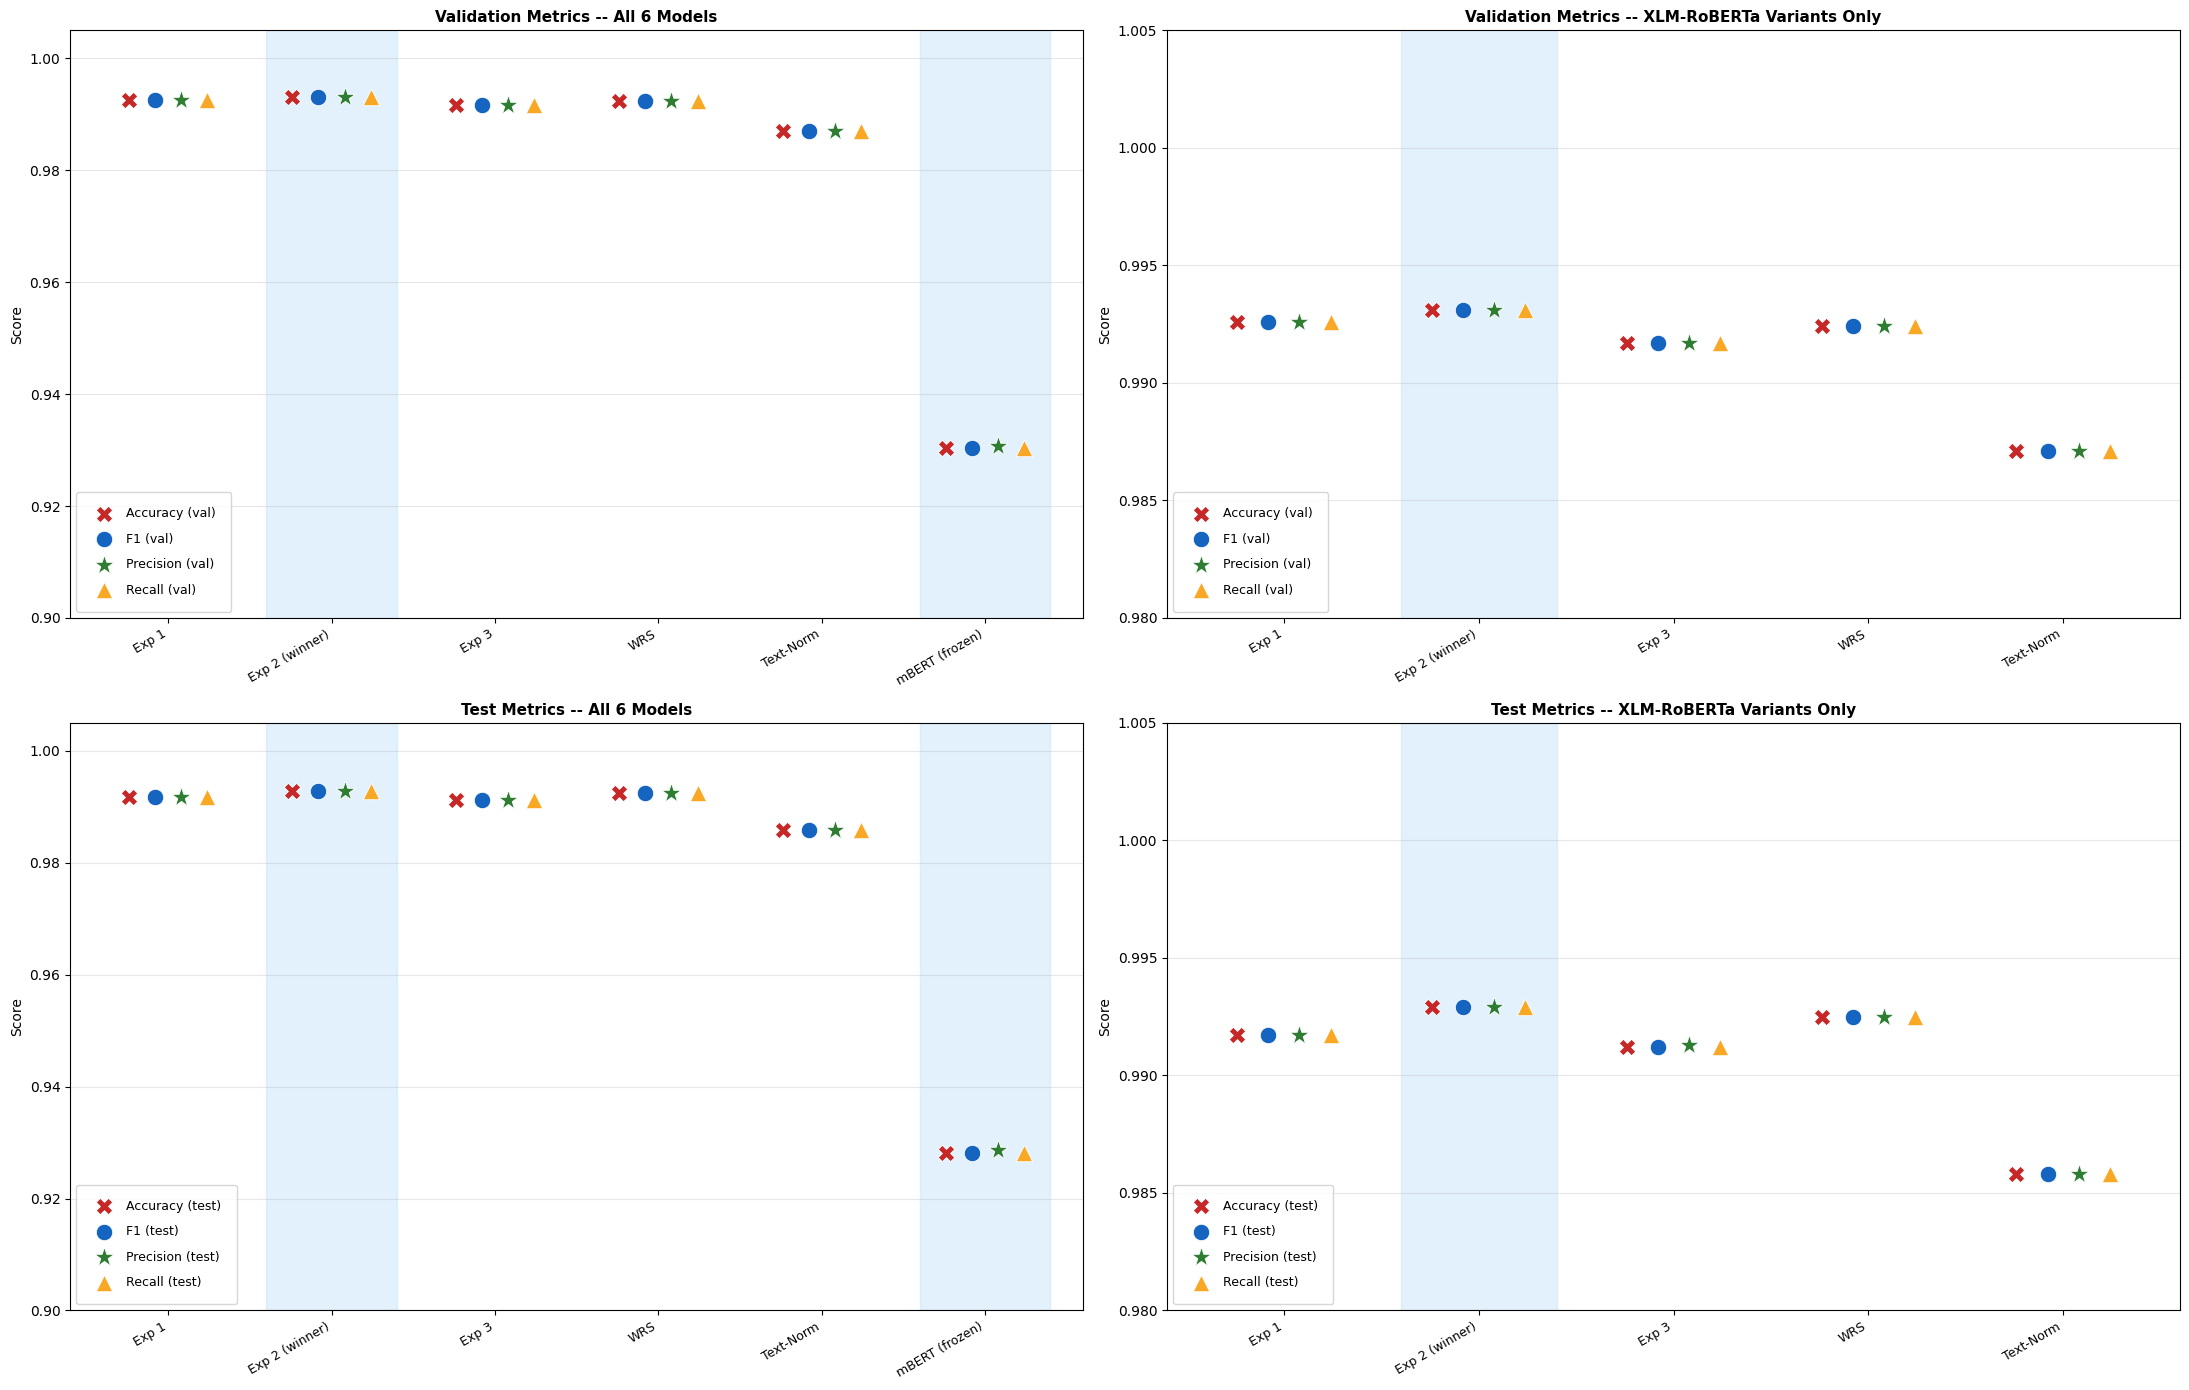

Saved: summary_comparison_all_experiments.png


In [21]:
# =============================================================================
# CELL 12b: Summary comparison charts -- all experiments, 4 key metrics
# =============================================================================
df_summary = df_experiment_summary.copy()   # already loaded in Cell 12
df_summary['display_label'] = df_summary['experiment'].apply(
    lambda x: ('mBERT (frozen)' if x == 'mBERT' else x) + (' (winner)' if x == best_xlm_experiment else ''))
df_summary.to_csv(f'{OUTPUT_DIR}/summary_comparison_all_experiments.csv', index=False)

print('Summary table (also saved as summary_comparison_all_experiments.csv):')
print(df_summary[['experiment', 'val_accuracy', 'val_f1', 'val_precision', 'val_recall',
                   'test_accuracy', 'test_f1', 'test_precision', 'test_recall']]
      .round(4).to_string(index=False))


def plot_metric_scatter(ax, df, metric_cols, metric_labels, title, highlight_mbert, ylim=(0.90, 1.005)):
    """Scatter 4 metrics per experiment on one axis; shade winner (and mBERT if present)."""
    x_pos   = np.arange(len(df))                            # one x position per experiment/model
    jitter  = 0.16   # widened from 0.06 so the 4 markers per experiment don't overlap
    markers = ['X', 'o', '*', '^']                           # distinct marker shape per metric
    sizes   = [140, 140, 220, 140]                           # marker sizes (star is bigger to stand out)
    colors  = ['#C62828', '#1565C0', '#2E7D32', '#F9A825']   # one colour per metric
    offsets = [-1.5 * jitter, -0.5 * jitter, 0.5 * jitter, 1.5 * jitter]   # horizontal spread per metric

    for col, label, marker, size, color, offset in zip(metric_cols, metric_labels, markers, sizes, colors, offsets):
        ax.scatter(x_pos + offset, df[col], marker=marker, s=size, color=color,   # plot one metric's points
                   label=label, zorder=3, edgecolors='white', linewidths=0.6)

    for idx, lbl in enumerate(df['display_label']):
        if '(winner)' in lbl or (highlight_mbert and 'mBERT' in lbl):
            ax.axvspan(idx - 0.4, idx + 0.4, color='#BBDEFB', alpha=0.4, zorder=0)   # shade the highlighted column

    ax.set_xticks(x_pos)
    ax.set_xticklabels(df['display_label'], rotation=30, ha='right', fontsize=9)   # angled labels to avoid overlap
    ax.set_xlim(-0.6, len(df) - 0.4)   # extra side margin so outer jittered points aren't clipped
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(loc='lower left', fontsize=9,
              borderpad=1.2, labelspacing=1.0, handletextpad=0.8, frameon=True)
    ax.grid(True, alpha=0.3, axis='y')


df_all6 = df_summary.reset_index(drop=True)                          # all 6 models (5 XLM variants + mBERT)
df_xlm5 = df_summary[df_summary['experiment'] != 'mBERT'].reset_index(drop=True)   # XLM-RoBERTa variants only

val_cols    = ['val_accuracy', 'val_f1', 'val_precision', 'val_recall']    # validation metric columns
val_labels  = ['Accuracy (val)', 'F1 (val)', 'Precision (val)', 'Recall (val)']
test_cols   = ['test_accuracy', 'test_f1', 'test_precision', 'test_recall']   # test metric columns
test_labels = ['Accuracy (test)', 'F1 (test)', 'Precision (test)', 'Recall (test)']

fig, axes = plt.subplots(2, 2, figsize=(22, 14))   # 2x2 grid: val/test rows x all-models/XLM-only columns

plot_metric_scatter(axes[0, 0], df_all6, val_cols, val_labels,
                     'Validation Metrics -- All 6 Models', highlight_mbert=True)
plot_metric_scatter(axes[0, 1], df_xlm5, val_cols, val_labels,
                     'Validation Metrics -- XLM-RoBERTa Variants Only', highlight_mbert=False,
                     ylim=(0.98, 1.005))
plot_metric_scatter(axes[1, 0], df_all6, test_cols, test_labels,
                     'Test Metrics -- All 6 Models', highlight_mbert=True)
plot_metric_scatter(axes[1, 1], df_xlm5, test_cols, test_labels,
                     'Test Metrics -- XLM-RoBERTa Variants Only', highlight_mbert=False,
                     ylim=(0.98, 1.005))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/summary_comparison_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: summary_comparison_all_experiments.png')

## 12c. Train vs test accuracy -- over/underfitting check

For each model, compares training accuracy against test accuracy and reports whether the
gap suggests overfitting, underfitting, or good generalisation.


In [27]:
# =============================================================================
# CELL 12c: Train vs Test Accuracy -- all models, with over/underfitting verdict
# =============================================================================
def fit_verdict(train_acc, test_acc, gap_thresh=0.05, low_thresh=0.85):
    gap = train_acc - test_acc                              # positive gap = train scored higher than test
    if train_acc < low_thresh and test_acc < low_thresh:
        return 'Likely UNDERFITTING (both scores low)'
    elif gap > gap_thresh:
        return 'Likely OVERFITTING (train notably higher than test)'
    else:
        return 'Generalises well (train approx. test)'

df_fit = df_experiment_summary[['experiment', 'train_accuracy', 'test_accuracy']].copy()   # only the columns needed
df_fit['Model'] = df_fit['experiment'].apply(lambda x: 'mBERT (frozen baseline)' if x == 'mBERT' else f'XLM-RoBERTa {x}')
df_fit = df_fit.rename(columns={'train_accuracy': 'Train Accuracy', 'test_accuracy': 'Test Accuracy'})   # nicer headers
df_fit['Gap (Train - Test)'] = (df_fit['Train Accuracy'] - df_fit['Test Accuracy']).round(4)   # overfitting signal
df_fit['Train Accuracy'] = df_fit['Train Accuracy'].round(4)
df_fit['Test Accuracy']  = df_fit['Test Accuracy'].round(4)
df_fit['Verdict'] = df_fit.apply(lambda r: fit_verdict(r['Train Accuracy'], r['Test Accuracy']), axis=1)   # label each row
df_fit = df_fit[['Model', 'Train Accuracy', 'Test Accuracy', 'Gap (Train - Test)', 'Verdict']]   # final column order

print("="*95)
print("TRAIN vs TEST ACCURACY TABLE")
print("="*95)
print(df_fit.to_string(index=False))
print("="*95)

df_fit.to_csv(f'{OUTPUT_DIR}/train_vs_test_accuracy.csv', index=False)
print(f"\nSaved: train_vs_test_accuracy.csv")


TRAIN vs TEST ACCURACY TABLE
                  Model  Train Accuracy  Test Accuracy  Gap (Train - Test)                               Verdict
      XLM-RoBERTa Exp 1          0.9990         0.9917              0.0073 Generalises well (train approx. test)
      XLM-RoBERTa Exp 2          0.9987         0.9929              0.0058 Generalises well (train approx. test)
      XLM-RoBERTa Exp 3          0.9969         0.9912              0.0057 Generalises well (train approx. test)
        XLM-RoBERTa WRS          0.9992         0.9925              0.0067 Generalises well (train approx. test)
  XLM-RoBERTa Text-Norm          0.9883         0.9858              0.0025 Generalises well (train approx. test)
mBERT (frozen baseline)          0.9328         0.9282              0.0046 Generalises well (train approx. test)

Saved: train_vs_test_accuracy.csv


## 13. Save best model + push to HuggingFace Hub

Selects the in-memory model object that corresponds to `best_model_name` (determined above),
saves it locally, and pushes it to HuggingFace Hub.


In [28]:
# =============================================================================
# CELL 13: Save best model to /kaggle/working + push to HuggingFace Hub
# -----------------------------------------------------------------------------
# HuggingFace Hub push creates a public model card at:
#   https://huggingface.co/Bhoovika/scamsense-xlmroberta-new
#   (or .../scamsense-mbert-new if mBERT wins)
# =============================================================================
from huggingface_hub import login
from transformers import AutoTokenizer

XLM_MODEL_NAME_FALLBACK   = 'xlm-roberta-base'
MBERT_MODEL_NAME_FALLBACK = 'bert-base-multilingual-cased'

# Checkpoint filenames are always f'{MODELS_DIR}/{run_name}_best.pt' -- fixed by train_model()
RUN_NAME_MAP = {
    'Exp 1': 'xlmroberta-exp1', 'Exp 2': 'xlmroberta-exp2', 'Exp 3': 'xlmroberta-exp3',
    'WRS': 'xlmroberta-wrs', 'Text-Norm': 'xlmroberta-normalised', 'mBERT': 'mbert-scamsense-baseline',
}

# best_model_name / best_f1 / best_xlm_experiment were already computed in Section 12 above --
# recompute from the CSVs only if this cell is somehow run on its own (e.g. a fresh kernel).
if 'best_model_name' not in dir() or 'best_f1' not in dir() or 'best_xlm_experiment' not in dir():
    df_experiment_summary = pd.read_csv(ALL_SUMMARY_CSV)
    df_all_perlang        = pd.read_csv(ALL_PERLANG_CSV)

    xlm_summary = df_experiment_summary[df_experiment_summary['experiment'] != 'mBERT']
    best_xlm_experiment = xlm_summary.loc[xlm_summary['test_f1'].idxmax(), 'experiment']

    df_best_xlm = df_all_perlang[df_all_perlang['experiment'] == best_xlm_experiment].copy()
    df_best_xlm['model'] = f'XLM-RoBERTa ({best_xlm_experiment})'
    df_mbert_labelled = df_all_perlang[df_all_perlang['experiment'] == 'mBERT'].copy()
    df_mbert_labelled['model'] = 'mBERT'
    df_all_check = pd.concat([df_best_xlm, df_mbert_labelled], ignore_index=True)
    df_overall_check = df_all_check[df_all_check['language'] == 'overall']
    best_model_name = df_overall_check.loc[df_overall_check['f1'].idxmax(), 'model']
    best_f1         = df_overall_check['f1'].max()

print(f"best_xlm_experiment = {best_xlm_experiment}")
print(f"best_model_name     = {best_model_name}")
print(f"best_f1             = {best_f1:.4f}")

# -- Resolve which checkpoint to load, purely from disk (no in-memory model objects needed) --
if best_model_name == 'mBERT':
    winning_label, base_model_id, hf_model_id, freeze_encoder = (
        'mBERT', MBERT_MODEL_NAME_FALLBACK, 'Bhoovika/scamsense-mbert-new1', True)
else:
    winning_label, base_model_id, hf_model_id, freeze_encoder = (
        best_xlm_experiment, XLM_MODEL_NAME_FALLBACK, 'Bhoovika/scamsense-xlmroberta-new1', False)

run_name       = RUN_NAME_MAP[winning_label]
best_ckpt_path = f'{MODELS_DIR}/{run_name}_best.pt'

if not os.path.exists(best_ckpt_path):
    raise FileNotFoundError(
        f"Checkpoint not found: {best_ckpt_path}\n"
        f"Run `print(sorted(os.listdir(MODELS_DIR)))` to see what's actually available."
    )

best_tokenizer = AutoTokenizer.from_pretrained(base_model_id)   # tokenizers are stateless -- safe to reload fresh
best_model     = build_model(base_model_id, freeze_encoder=freeze_encoder)
best_model.load_state_dict(torch.load(best_ckpt_path))
best_model.eval()

# -- Save to /kaggle/working/models/scamsense_best_model/ --
save_path = f'{MODELS_DIR}/scamsense_best_model'
os.makedirs(save_path, exist_ok=True)
best_model.save_pretrained(save_path)
best_tokenizer.save_pretrained(save_path)
print(f'Model saved to: {save_path}')
print('Download from Kaggle output panel -> models/scamsense_best_model/')

# -- Push to HuggingFace Hub --
try:
    HF_TOKEN = secrets.get_secret('HF_TOKEN')
    login(token=HF_TOKEN)
    best_model.push_to_hub(hf_model_id)
    best_tokenizer.push_to_hub(hf_model_id)
    print(f'Pushed to: https://huggingface.co/{hf_model_id}')
except Exception as e:
    print(f'HF push skipped -- add HF_TOKEN to Kaggle Secrets to enable.')
    print(f'Error: {e}')

print(f'Best model: {best_model_name} | F1: {best_f1:.4f}')
print(f'MLflow: https://dagshub.com/Bhoovika/ScamSense.mlflow')


best_xlm_experiment = Exp 2
best_model_name     = XLM-RoBERTa (Exp 2)
best_f1             = 0.9929


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Full fine-tune: 278,045,186 params trainable


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/models/scamsense_best_model
Download from Kaggle output panel -> models/scamsense_best_model/


...

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed to: https://huggingface.co/Bhoovika/scamsense-xlmroberta-new1
Best model: XLM-RoBERTa (Exp 2) | F1: 0.9929
MLflow: https://dagshub.com/Bhoovika/ScamSense.mlflow
